# Predicting 30-Day Hospital Readmission Risk Among Diabetic Emergency Inpatient Admissions Using Machine Learning

### Clinical Data Science Project

## Clinical Problem

Hospital readmissions within 30 days are a major challenge in healthcare because they can indicate gaps in care coordination, medication management, patient education, or chronic disease management. Patients with diabetes are at increased risk of complications that may lead to repeated hospital visits.

The goal of this project is to develop a machine learning model that identifies patients at higher risk of being readmitted within 30 days after a diabetes-related hospitalization.

## Business Problem

Healthcare organizations need tools that can identify high-risk patients early so care teams can prioritize interventions, improve care management, reduce preventable readmissions, and potentially lower healthcare costs.

This project aims to support population health management by using electronic health record (EHR) data to predict readmission risk and provide insights into factors associated with higher risk.


## Dataset Overview

This project uses the **Diabetes 130-US Hospitals dataset**, which contains diabetes hospital encounter data from patients with diabetes collected from 130 U.S. hospitals.

The dataset includes patient demographic information, clinical measurements, medications, and healthcare utilization features. This study focuses on identifying factors associated with **30-day hospital readmission** among patients with diabetes who experienced emergency inpatient admissions.

### Dataset Information:

- Contains **101,766 diabetes hospital encounters** from patients with diabetes
- Collected from **130 U.S. hospitals**
- Includes demographic, clinical, medication, and healthcare utilization variables
- The prediction outcome is **30-day hospital readmission**
- Used to identify factors associated with increased readmission risk and develop a machine-learning-ready dataset

## Project Objective

The objective of this project is to identify demographic, clinical, and healthcare utilization factors associated with 30-day hospital readmission among patients with diabetes who experienced emergency inpatient admissions. The project also aims to develop a machine-learning-ready dataset and evaluate predictive models for identifying patients at elevated risk of readmission.


## Research Question

Which demographic, clinical, and healthcare utilization factors are associated with 30-day hospital readmission among diabetic emergency inpatient admissions?

## Project Workflow

This project follows an end-to-end clinical data science and machine-learning workflow:

1. Project Objective & Research Question
2. Data Understanding & Dataset Overview
3. Data Quality Assessment
4. Data Cleaning & Preprocessing
5. Cohort Definition
6. Cohort Validation
7. Exploratory Data Analysis
8. Feature Engineering
9. Final ML Dataset Construction
10. Train/Test Split
11. Baseline Model Development
12. Baseline Model Evaluation
13. Hyperparameter Tuning
14. Baseline vs. Tuned Model Comparison
15. Final Candidate Model Selection
16. Probability Calibration Analysis
17. Classification Threshold Optimization
18. Final Model Evaluation & Decision
19. Final Logistic Regression Feature Interpretation
20. Model Limitations & Future Improvements
21. Project Conclusion
22. Model Deployment

## Tools Used

- Python
- SQL Server
- SQL
- Pandas
- NumPy
- Scikit-learn
- Jupyter Notebook
- VS Code
- Tableau Public
- Streamlit
- GitHub

## Import Libraries

In [1]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SQL Database Connection

The diabetes dataset is stored in Microsoft SQL Server. A connection is established using Python to retrieve patient encounter data for analysis.

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

# Part 1: Data Extraction and Loading

The diabetes dataset was extracted from SQL Server using an SQL query and loaded into a pandas DataFrame for analysis. The DataFrame served as the primary dataset for subsequent data validation, data cleaning, cohort selection, exploratory data analysis (EDA), feature engineering, visualization, and machine learning model development..

In [3]:
query = "SELECT * FROM dbo.diabetes_data"
df = pd.read_sql(query, conn)

C:\Users\davon\AppData\Local\Temp\ipykernel_10400\2882961085.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


# Part 2: Data Understanding & Preparation

## 2.1 Understanding the Data

The dataset is inspected to verify successful extraction, review its structure, and identify potential data quality issues before cleaning.

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
1,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
3,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [5]:
df.shape

(101766, 50)

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  object
 7   discharge_disposition_id  101766 non-null  object
 8   admission_source_id       101766 non-null  object
 9   time_in_hospital          101766 non-null  object
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  object
 13  num_procedures            101766 non-null  object
 14  num_

### Data Understanding Interpretation

- The dataset contains **101,766 hospital encounters** and **50 variables**.
- The target variable is `readmitted`, which represents the patient readmission outcome.
- The dataset includes both numerical and object variables.

## 2.2 Summary Statistics

The following table provides a statistical summary of both numerical and categorical variables, including central tendency, dispersion, and frequency distribution.

In [8]:
df.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,8,26,17,14,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,1,1,7,3,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,53990,60234,57494,17756,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Key Observations:

* The target variable **`readmitted` contained three categories** (`NO`, `>30`, and `<30`) and was transformed into a binary classification outcome to predict 30-day readmission.

* Missing values were represented as **"?"**, requiring conversion and handling during the data cleaning process.

* Identifier variables such as **`encounter_id` and `patient_nbr`** were evaluated and excluded from predictive modeling because they do not represent meaningful clinical predictors.

### 2.2 Data Quality Check

This section evaluates the dataset for missing values, duplicate records, unique value counts, and inconsistent data entries to assess data integrity prior to feature engineering and modeling.

In [9]:
df.isna().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

encounter_id                101766
patient_nbr                  71518
race                             6
gender                           3
age                             10
weight                          10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      18
medical_specialty               73
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         717
diag_2                         749
diag_3                         790
number_diagnoses                16
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

In [12]:
(df=="?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [13]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

encounter_id: 0 outliers
patient_nbr: 247 outliers


### Data Quality Assessment Summary

The dataset was evaluated for data quality issues before modeling:

- Checked missing values (`NaN` and "?")
- Checked duplicate records
- Reviewed unique values and data types
- Assessed potential outliers using the IQR method

Some numerical variables contained extreme values, but they were considered realistic encounters that may represent patients with higher healthcare utilization or more severe illness. Therefore, no outliers were removed before model development.

## 2.3 Transformation and Standardization

Variables were transformed and standardized to improve data consistency and prepare the dataset for analysis and machine learning. This included handling missing values, converting variables into appropriate formats, creating clinically meaningful categories such as age groups, mapping demographic variables, and renaming features to improve readability and interpretation..

In [14]:
df.rename(columns={
    "A1Cresult": "a1c_result",
    "diabetesMed": "diabetes_medication", "change":"change_medication", "num_lab_procedures":"number_lab_procedures",
    "num_procedures":"number_procedures", "num_medications":"number_medications","number_inpatient":"number_inpatient_visits"
}, inplace=True)

df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient_visits',
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum',
       'a1c_result', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change_medication', 'diabetes_medication',
       'readmitted'],
      dtype='object')

In [15]:
(df == "?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
number_lab_procedures           0
number_procedures               0
number_medications              0
number_outpatient               0
number_emergency                0
number_inpatient_visits         0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
a1c_result                      0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [16]:
df.replace(["?", "NA", "N/A"],np.nan,inplace=True)

In [17]:
df.isin(["?", "NA", "N/A"]).sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
number_lab_procedures       0
number_procedures           0
number_medications          0
number_outpatient           0
number_emergency            0
number_inpatient_visits     0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
a1c_result                  0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [18]:
race_map = {
    "Caucasian": "White",
    "AfricanAmerican": "Black",
    "asian": "Asian",
    "other": "Other",
    "hispanic": "Hispanic"
}

df["race"] = df["race"].replace(race_map)
df["race"].unique()

array(['White', 'Black', nan, 'Other', 'Asian', 'Hispanic'], dtype=object)

In [19]:
num_cols = [
    "time_in_hospital",
    "number_lab_procedures",
    "number_procedures",
    "number_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient_visits",
    "number_diagnoses"
]

df[num_cols] = df[num_cols].astype(int)
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
number_lab_procedures        int64
number_procedures            int64
number_medications           int64
number_outpatient            int64
number_emergency             int64
number_inpatient_visits      int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
a1c_result                  object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [20]:
age_map = {

    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age"] = df["age"].replace(age_map)
df["age"] = df["age"].astype("int64")
df["age"].value_counts().sort_index()

C:\Users\davon\AppData\Local\Temp\ipykernel_10400\2883879645.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age"] = df["age"].replace(age_map)


age
5       161
15      691
25     1657
35     3775
45     9685
55    17256
65    22483
75    26068
85    17197
95     2793
Name: count, dtype: int64

In [21]:
cat_cols = [
    "race", "gender",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "change_medication",
    "diabetes_medication",
    "readmitted",
    "insulin",
]

cat_cols = [col for col in cat_cols if col in df.columns]

df[cat_cols] = df[cat_cols].astype("category")
df[cat_cols].dtypes

race                        category
gender                      category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
change_medication           category
diabetes_medication         category
readmitted                  category
insulin                     category
dtype: object

In [22]:
df["diag_1"] = pd.to_numeric(df["diag_1"], errors="coerce")
df["diag_2"] = pd.to_numeric(df["diag_2"], errors="coerce")
df["diag_3"] = pd.to_numeric(df["diag_3"], errors="coerce")

In [23]:
df[["diag_1", "diag_2", "diag_3"]].dtypes

diag_1    float64
diag_2    float64
diag_3    float64
dtype: object

In [24]:
df["diag_1_group"] = "Other"
df.loc[(df["diag_1"] >= 250) & (df["diag_1"] < 251), "diag_1_group"] = "Diabetes"
df.loc[(df["diag_1"] >= 401) & (df["diag_1"] < 405), "diag_1_group"] = "Hypertension"
df.loc[(df["diag_1"] >= 414) & (df["diag_1"] < 416), "diag_1_group"] = "Heart_Disease"

df["diag_2_group"] = "Other"
df.loc[(df["diag_2"] >= 250) & (df["diag_2"] < 251), "diag_2_group"] = "Diabetes"
df.loc[(df["diag_2"] >= 401) & (df["diag_2"] < 405), "diag_2_group"] = "Hypertension"
df.loc[(df["diag_2"] >= 414) & (df["diag_2"] < 416), "diag_2_group"] = "Heart_Disease"

df["diag_3_group"] = "Other"
df.loc[(df["diag_3"] >= 250) & (df["diag_3"] < 251), "diag_3_group"] = "Diabetes"
df.loc[(df["diag_3"] >= 401) & (df["diag_3"] < 405), "diag_3_group"] = "Hypertension"
df.loc[(df["diag_3"] >= 414) & (df["diag_3"] < 416), "diag_3_group"] = "Heart_Disease"

df[["diag_1_group", "diag_2_group", "diag_3_group"]].head()

,diag_1_group,diag_2_group,diag_3_group
0,Other,Other,Other
1,Other,Other,Other
2,Other,Other,Diabetes
3,Diabetes,Hypertension,Other
4,Heart_Disease,Other,Diabetes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      99493 non-null   category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  int64   
 5   weight                    3197 non-null    object  
 6   admission_type_id         101766 non-null  category
 7   discharge_disposition_id  101766 non-null  category
 8   admission_source_id       101766 non-null  category
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                61510 non-null   object  
 11  medical_specialty         51817 non-null   object  
 12  number_lab_procedures     101766 non-null  int64   
 13  number_procedures         101

### Data Standardization Interpretation:

* The dataset has been successfully standardized, improving consistency and interpretability of clinical variables.

* Categorical values were reviewed and standardized, including race categories and missing value representations.

* ICD diagnosis features ('diag_1,' 'diag_2,' and 'diag_3') were transformed into grouped clinical categories to improve model interpretability and reduce feature complexity.

* Column names were standardized to improve readability and maintain consistency throughout the analysis workflow.

* These transformations created a cleaner dataset that is better prepared for data cleaning, exploratory analysis, and machine learning preparation.

* The next steps will focus on validating data quality, addressing remaining missing values, encoding categorical variables, and preparing features for predictive modeling.

# Part 3 :Data Cleaning

Clinical datasets often contain missing values, inconsistent categories, and incorrect data types. Cleaning improves data quality and prepares the dataset for analysis and machine learning.

In [26]:
df[["diag_1", "diag_2", "diag_3"]].isna().sum()

diag_1    1666
diag_2    2894
diag_3    6481
dtype: int64

In [27]:
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

df[["diag_1", "diag_2", "diag_3"]].isnull().sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

In [28]:
df.drop(columns=[
    'weight', 'payer_code', 'medical_specialty', 'number_outpatient',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'glyburide_metformin',
    'glipizide_metformin', 'glimepiride_pioglitazone',
    'metformin_rosiglitazone', 'metformin_pioglitazone',
    'discharge_disposition_id'
], inplace=True, errors='ignore')

df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'admission_source_id', 'time_in_hospital',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_emergency', 'number_inpatient_visits', 'diag_1', 'diag_2',
       'diag_3', 'number_diagnoses', 'max_glu_serum', 'a1c_result', 'insulin',
       'change_medication', 'diabetes_medication', 'readmitted',
       'diag_1_group', 'diag_2_group', 'diag_3_group'],
      dtype='object')

### Data Cleaning Interpretation:

* Removed variables with substantial missing data (e.g., 'weight,' 'payer_code,' and `medical_specialty') because they were unlikely to provide reliable predictive information.

* Removed medication-specific variables due to high sparsity and limited expected contribution to the predictive model.

* Excluded `number_outpatients' to maintain focus on inpatient encounter-related factors.

* Removed `discharge_disposition_id' to reduce potential data leakage risk because it may contain information only available after or during the discharge process.

* These feature reduction steps improved data quality, reduced dataset complexity, and created a more interpretable dataset for exploratory analysis and machine learning.

 # Part 4: Data Validation

After cleaning and standardization, the dataset is validated to confirm that transformations were applied correctly and that the data are ready for analysis.

In [29]:
df.isna().sum()

encounter_id                  0
patient_nbr                   0
race                       2273
gender                        0
age                           0
admission_type_id             0
admission_source_id           0
time_in_hospital              0
number_lab_procedures         0
number_procedures             0
number_medications            0
number_emergency              0
number_inpatient_visits       0
diag_1                        0
diag_2                        0
diag_3                        0
number_diagnoses              0
max_glu_serum                 0
a1c_result                    0
insulin                       0
change_medication             0
diabetes_medication           0
readmitted                    0
diag_1_group                  0
diag_2_group                  0
diag_3_group                  0
dtype: int64

In [30]:
df["race"] = df["race"].astype("object").fillna("Unknown")

In [31]:
print(df["race"].isna().sum())
print(df["race"].value_counts(dropna=False))

0
race
White       76099
Black       19210
Unknown      2273
Hispanic     2037
Other        1506
Asian         641
Name: count, dtype: int64


In [32]:
df.dtypes

encounter_id                  int64
patient_nbr                   int64
race                         object
gender                     category
age                           int64
admission_type_id          category
admission_source_id        category
time_in_hospital              int64
number_lab_procedures         int64
number_procedures             int64
number_medications            int64
number_emergency              int64
number_inpatient_visits       int64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses              int64
max_glu_serum                object
a1c_result                   object
insulin                    category
change_medication          category
diabetes_medication        category
readmitted                 category
diag_1_group                 object
diag_2_group                 object
diag_3_group                 object
dtype: object

In [33]:
df.shape

(101766, 26)

In [34]:
df.describe()

,encounter_id,patient_nbr,age,time_in_hospital,number_lab_procedures,number_procedures,number_medications,number_emergency,number_inpatient_visits,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,65.967022,4.395987,43.095641,1.339730,16.021844,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,15.940838,2.985108,19.674362,1.705807,8.127566,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,95.000000,14.000000,132.000000,6.000000,81.000000,76.000000,21.000000,16.000000


In [35]:
df["race"].unique()

array(['White', 'Black', 'Unknown', 'Other', 'Asian', 'Hispanic'],
      dtype=object)

In [36]:
df["gender"].unique()

['Female', 'Male', 'Unknown/Invalid']
Categories (3, object): ['Female', 'Male', 'Unknown/Invalid']

In [37]:
df["age"].unique()

array([85, 95, 45, 55, 65, 75, 25, 15, 35,  5])

In [38]:
(df == "?").sum()

encounter_id               0
patient_nbr                0
race                       0
gender                     0
age                        0
admission_type_id          0
admission_source_id        0
time_in_hospital           0
number_lab_procedures      0
number_procedures          0
number_medications         0
number_emergency           0
number_inpatient_visits    0
diag_1                     0
diag_2                     0
diag_3                     0
number_diagnoses           0
max_glu_serum              0
a1c_result                 0
insulin                    0
change_medication          0
diabetes_medication        0
readmitted                 0
diag_1_group               0
diag_2_group               0
diag_3_group               0
dtype: int64

In [39]:
df.isnull().sum()

encounter_id               0
patient_nbr                0
race                       0
gender                     0
age                        0
admission_type_id          0
admission_source_id        0
time_in_hospital           0
number_lab_procedures      0
number_procedures          0
number_medications         0
number_emergency           0
number_inpatient_visits    0
diag_1                     0
diag_2                     0
diag_3                     0
number_diagnoses           0
max_glu_serum              0
a1c_result                 0
insulin                    0
change_medication          0
diabetes_medication        0
readmitted                 0
diag_1_group               0
diag_2_group               0
diag_3_group               0
dtype: int64

### Data Validation Interpretation:

* Missing value checks confirmed that most variables contain **no remaining missing values** after data cleaning.

* The `race` feature initially contained **2,273 missing values**, which were successfully replaced with an **"Unknown" category** to preserve patient records.

* Diagnosis variables (**`diag_1`, `diag_2`, and **`diag_3`**) were validated after replacing missing entries represented by **`?`** with **"Unknown," resulting in no remaining missing values.

* Data standardization steps were verified to ensure categorical variables contained consistent labels and formatting.

* Data types and unique value counts were reviewed to identify potential issues before feature engineering and machine learning.

* The cleaned dataset is now ready for the next stage of the workflow

## Save Clean Dataset to Jupyter File

In [40]:
df.to_csv('diabetes_clean.csv', index=False)
print("Data saved to CSV file!")

Data saved to CSV file!


## Save Clean Dataset to SQL Server

In [41]:
from sqlalchemy import create_engine
import urllib.parse

In [42]:
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

connection_url = urllib.parse.quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_url}"
)

In [43]:
df.to_sql(
    name="diabetes_data_clean",
    con=engine,
    if_exists="replace",
    index=False
)

C:\Users\davon\New folder\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


6

## Data Preparation Summary

The dataset was successfully cleaned, standardized, and validated for downstream analysis. Missing values were handled appropriately, categorical variables were standardized for consistency, and diagnosis codes were grouped into clinically meaningful categories through ICD-based feature engineering. Variables with excessive missingness, limited analytical value, or potential for data leakage were removed to improve data quality and model reliability. The cleaned dataset was validated to ensure all transformations were applied correctly and was then saved in two locations:

* **Jupyter Notebook Project Folder:** `diabetes_data_clean.csv`
* **SQL Server:** `dbo.diabetes_data_clean`

Saving the cleaned dataset in both locations provides a reproducible analytical dataset that can be used for SQL cohort extraction, exploratory data analysis, feature engineering, and machine learning without modifying the original raw data.

# Part 5: SQL Cohort Extraction (SQL)

This cohort definition ensures the analysis focuses specifically on acute diabetes-related hospital encounters rather than all diabetes patients.

In [44]:
query="""
SELECT*
FROM dbo.diabetes_data_clean
WHERE (
diag_1 LIKE '250%'OR 
diag_2 LIKE '250%'OR 
diag_3 LIKE '250%'
)
AND admission_type_id=1
"""
df = pd.read_sql(query,conn)
df.head()

C:\Users\davon\AppData\Local\Temp\ipykernel_10400\1525260284.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,number_lab_procedures,number_procedures,...,number_diagnoses,max_glu_serum,a1c_result,insulin,change_medication,diabetes_medication,readmitted,diag_1_group,diag_2_group,diag_3_group
0,16680,42519267,White,Male,45,1,7,1,51,0,...,5,None,None,Steady,Ch,Yes,NO,Other,Other,Diabetes
1,28236,89869032,Black,Female,45,1,7,9,47,2,...,9,None,None,Steady,No,Yes,>30,Diabetes,Hypertension,Other
2,40926,85504905,White,Female,45,1,7,7,60,0,...,8,None,None,Down,Ch,Yes,<30,Other,Diabetes,Diabetes
3,63768,114882984,White,Male,75,1,7,5,73,0,...,8,None,None,No,No,Yes,>30,Other,Other,Diabetes
4,64410,86047875,Black,Female,25,1,7,2,11,5,...,6,None,None,No,No,Yes,NO,Other,Diabetes,Other


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   encounter_id             19689 non-null  int64 
 1   patient_nbr              19689 non-null  int64 
 2   race                     19689 non-null  object
 3   gender                   19689 non-null  object
 4   age                      19689 non-null  int64 
 5   admission_type_id        19689 non-null  object
 6   admission_source_id      19689 non-null  object
 7   time_in_hospital         19689 non-null  int64 
 8   number_lab_procedures    19689 non-null  int64 
 9   number_procedures        19689 non-null  int64 
 10  number_medications       19689 non-null  int64 
 11  number_emergency         19689 non-null  int64 
 12  number_inpatient_visits  19689 non-null  int64 
 13  diag_1                   19689 non-null  object
 14  diag_2                   19689 non-nul

## SQL Cohort Extraction Interpretation

The study cohort consists of emergency hospital encounters involving patients with diabetes-related diagnoses. Diabetes cases were identified using ICD-9 diagnosis codes beginning with **"250 %"** appearing in any of the primary diagnosis fields (**diag_1, diag_2, or diag_3**). The cohort was further restricted to emergency admissions (**admission_type_id = 1**) to focus on acute care presentations.

After applying these inclusion criteria, the extracted dataset contained **19,689 hospital encounters and 26 features/variables, including demographic, clinical, and utilization-related variables**. Each row represents an individual hospital encounter, while patient_nbr allows identification of repeated encounters from the same patient. This encounter-level structure supports analysis of healthcare utilization patterns and development of predictive models for diabetes-related readmission risk.

# Part 6: Cohort Analysis

This section summarizes baseline demographic characteristics, healthcare utilization, and clinic risk factor patterns within the diabetic inpatient cohort. 

## 6.1 Patient Demographics Characteristics

Understanding patient demographics provides important context about the population included in this study. 
Age, gender, and race distributions were examined to identify the characteristics of patients hospitalized with diabetes.

In [46]:
df["age"].value_counts(normalize=True) * 100

age
55    19.493118
75    19.305196
65    18.675403
45    14.622378
85    12.052415
35     7.176596
25     4.027630
15     2.128092
95     1.985880
5      0.533293
Name: proportion, dtype: float64

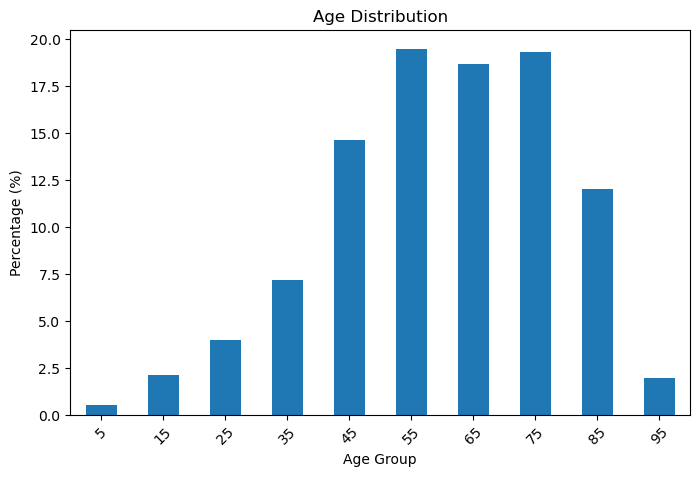

In [47]:
age_percent = df["age"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
age_percent.sort_index().plot(kind="bar")

plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

In [48]:
df["gender"].value_counts(normalize=True) * 100

gender
Female    54.416171
Male      45.583829
Name: proportion, dtype: float64

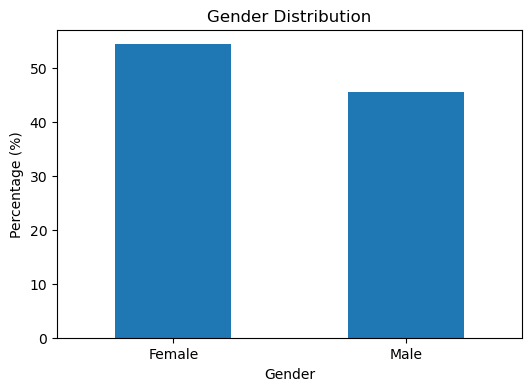

In [49]:
gender_percent = df["gender"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
gender_percent.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [50]:
df["race"].value_counts(normalize=True) * 100

race
White       66.544771
Black       27.426482
Hispanic     2.275382
Unknown      2.026512
Other        1.295139
Asian        0.431713
Name: proportion, dtype: float64

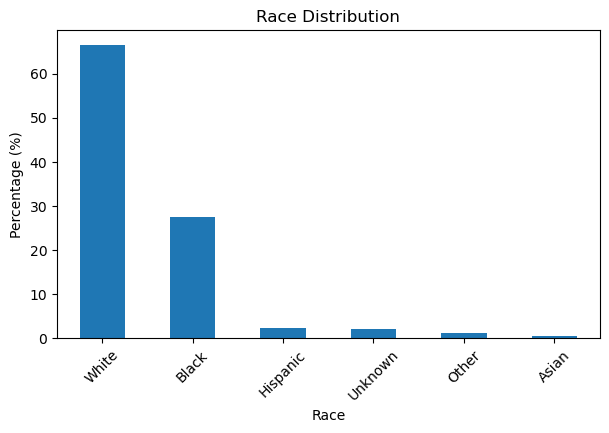

In [51]:
race_percent = df["race"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,4))
race_percent.plot(kind="bar")

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

### Demographic Cohort Stratification

In [52]:
df_grouped = (
    df.groupby(["age", "race", "gender"])
      .size()
      .reset_index(name="total_patients")
      .sort_values("total_patients", ascending=False)
      .reset_index(drop=True)
)

df_grouped.head(10)

,age,race,gender,total_patients
0,75,White,Female,1472
1,75,White,Male,1281
2,65,White,Male,1269
3,65,White,Female,1227
4,55,White,Male,1212
5,55,White,Female,1203
6,85,White,Female,1129
7,45,White,Male,898
8,45,White,Female,768
9,85,White,Male,750


### Demographic Findings and Cohort Stratification

A demographic analysis was performed to understand the composition of the diabetic inpatient cohort using age, race, and gender characteristics.

**The diabetic inpatient population was primarily composed of older adults, with patients aged 55, 65, and 75 years representing the largest age groups.** This finding describes the age distribution of diabetes-related inpatient encounters within the cohort.

**Gender distribution was relatively balanced, with females representing approximately 54% of the cohort and males representing approximately 46%.** This indicates that both male and female patients were represented within the inpatient population.

**The majority of encounters involved White patients (approximately 67%), followed by Black patients (approximately 27%), while other racial groups represented smaller proportions of the dataset.** These findings describe the demographic composition of the cohort and do not suggest that race alone determines readmission risk.

**A stratified analysis combining age, race, and gender showed that the highest-frequency demographic groups were concentrated among older adults, with White patients contributing the largest share of these demographic combinations.**

These findings describe the distribution of **healthcare encounters within the study cohort**. Because the dataset contains **inpatient encounters rather than unique patients**, individuals with multiple hospital admissions may contribute more than one observation.

Demographic characteristics provide important context about the patient population; however, **readmission risk may be influenced by additional clinical and healthcare utilization factors beyond demographics alone**. Further analysis will examine **clinical characteristics, utilization patterns, and diabetes management indicators associated with readmission outcomes.**


## 6.2 Hospitalization Characteristics and Healthcare Utilization

In [53]:
df["time_in_hospital"].value_counts().sort_index()

time_in_hospital
1     3236
2     4186
3     3626
4     2625
5     1771
6     1227
7      920
8      627
9      414
10     345
11     232
12     210
13     149
14     121
Name: count, dtype: int64

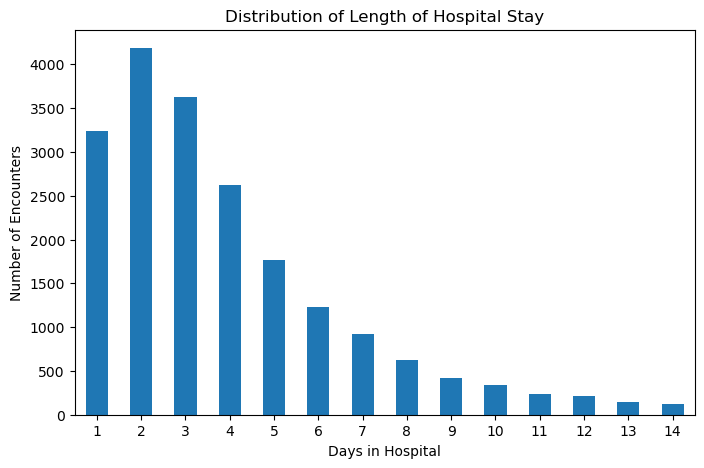

In [54]:
hospital_days = df["time_in_hospital"].value_counts().sort_index()

plt.figure(figsize=(8,5))
hospital_days.plot(kind="bar")

plt.title("Distribution of Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)

plt.show()

### Hospital Utilization (Length of Stay)

Hospital length of stay demonstrated a right-skewed distribution, with the majority of diabetes-related admissions lasting between **1 and 4 days**.

Longer hospitalizations became progressively less frequent, suggesting that most encounters represented shorter acute care episodes, while a smaller group of patients required extended inpatient resources.

Length of stay was examined as a potential indicator of clinical complexity and healthcare utilization patterns that may contribute to future readmission risk.

In [55]:
df["time_in_hospital"] = pd.to_numeric(
    df["time_in_hospital"], 
    errors='coerce'
)

print("Mean Length of Stay:", df["time_in_hospital"].mean())

print("Median Length of Stay:", df["time_in_hospital"].median())

print("Mode Length of Stay:", df["time_in_hospital"].mode())

Mean Length of Stay: 3.8873482655289755
Median Length of Stay: 3.0
Mode Length of Stay: 0    2
Name: time_in_hospital, dtype: int64


### Hospital Length of Stay Summary

Summary statistics were calculated to understand typical hospitalization duration within the diabetes inpatient cohort.

The distribution of hospital length of stay showed that most diabetes-related admissions were relatively short. The **average length of stay was approximately 3.9 days**, with a **median hospitalization duration of 3 days**. The most common hospitalization length was **2 days**, indicating that many encounters involved shorter inpatient stays.

The mean length of stay was slightly higher than the median, suggesting a **right-skewed distribution**. This indicates that while most patients experienced shorter hospitalizations, a smaller group of patients required longer inpatient care, increasing the overall average length of stay.

## Total Encounters Per Patient

In [56]:
encounters_per_patient = df.groupby("patient_nbr")["encounter_id"].count()
encounters_per_patient.head()

patient_nbr
135     1
927     1
1152    3
1314    2
5220    1
Name: encounter_id, dtype: int64

## How Many Patients Had 1, 2, or 3+ Observed Encounters?

In [57]:
print(encounters_per_patient.value_counts().sort_index())

print("Mean:", encounters_per_patient.mean())

print("Median:", encounters_per_patient.median())

print("Mode:", encounters_per_patient.mode()[0])

encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64
Mean: 1.194068773121475
Median: 1.0
Mode: 1


### Patient-Level Healthcare Utilization

Patient-level utilization was evaluated by calculating the number of **observed hospital encounters** associated with each patient identifier (`patient_nbr`) within the study cohort.

Most patients had only **one observed hospital encounter** in the dataset. The average number of observed encounters per patient was approximately **1.19**, with both the median and mode equal to **1 encounter**.

A smaller subset of patients had multiple observed encounters, with some patients having substantially more encounters than the typical patient. This analysis provides context on healthcare utilization patterns within the cohort and helped identify the presence of repeated hospital encounters.

Because encounter timestamps were not available to reliably establish whether these encounters occurred **before or after** a specific hospitalization, this patient-level count was used for **descriptive analysis only** and was not treated as a confirmed measure of prior utilization in the final predictive model.

## High Utilization Patients (3+ Observed Encounters)

In [58]:
high_utilizers = encounters_per_patient[
    encounters_per_patient >= 3
]

len(high_utilizers)

579

In [59]:
encounters_per_patient.value_counts().sort_index()

encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64

#### High Utilization Patients (3+ Observed Encounters)

Patients with **3 or more observed hospital encounters** within the study cohort were identified to examine the size of the higher-utilization subgroup.

A total of **579 patients** had 3 or more observed hospital encounters.

This analysis was used for **descriptive purposes** to understand repeated hospital encounters within the cohort. Because encounter timestamps were not available to confirm whether these encounters occurred before or after a specific hospitalization, this classification was not interpreted as confirmed prior utilization and was not used as a standalone predictive feature in the final machine-learning model.

## Inpatient Utilization Feature

The distribution of encounters per patient was evaluated during exploratory data analysis to understand healthcare utilization patterns.

The total encounter count calculated across the complete dataset was **not added back to the dataset as a machine-learning feature** because doing so could incorporate information from encounters occurring after the index encounter and introduce temporal leakage.

The encounter-count analysis is therefore retained for **EDA only**. Only information available at the prediction point should be used as a model predictor.

In [60]:


encounters_per_patient = (
    df.groupby("patient_nbr")["encounter_id"]
    .count()
)

print("Encounter counts per patient:")
print(encounters_per_patient.head())

print("\nEncounter Count Distribution:")
print(
    encounters_per_patient
    .value_counts()
    .sort_index()
)

print("\nMean:", round(encounters_per_patient.mean(), 3))
print("Median:", encounters_per_patient.median())
print("Mode:", encounters_per_patient.mode()[0])

Encounter counts per patient:
patient_nbr
135     1
927     1
1152    3
1314    2
5220    1
Name: encounter_id, dtype: int64

Encounter Count Distribution:
encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64

Mean: 1.194
Median: 1.0
Mode: 1


## Inpatient Utilization Feature

The distribution of encounters per patient was evaluated during exploratory data analysis to understand healthcare utilization patterns.

The total encounter count calculated across the complete dataset was **not added back to the encounter-level dataset as a machine-learning feature** because doing so could incorporate information from encounters occurring after the index encounter and introduce temporal leakage.

The encounter-count analysis was therefore retained for **EDA only**. Only information available at the prediction point should be used as a model predictor.

## Distribution of Patient Encounter Counts

The distribution of total observed encounters per patient was examined during exploratory data analysis to characterize healthcare utilization within the study cohort.

This analysis was retained for **descriptive purposes only** and was not used to create a machine-learning feature. Avoiding the use of the full-dataset encounter count as a predictor helps prevent potential temporal leakage from encounters occurring after the index encounter.

## Check Distribution of Total Encounters per Patient

In [61]:
encounter_count_distribution = (
    encounters_per_patient
    .value_counts()
    .sort_index()
)

encounter_count_distribution.index.name = "Number of Encounters"

encounter_count_distribution.name = "Number of Patients"

encounter_count_distribution

Number of Encounters
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: Number of Patients, dtype: int64

## 6.3 Clinical Characteristics and Diabetes Management Indicators

Clinical variables provide important information about diabetes severity and disease management. This section examines laboratory and treatment-related features that may be associated with early hospital readmission.

The following clinical features are evaluated:

- Hemoglobin A1C results
- Maximum glucose serum measurements
- Insulin therapy changes
- Medication changes

These variables may capture differences in diabetes control and treatment complexity that influence readmission risk.   

### Distribution of A1C results

In [62]:
df["a1c_result"].value_counts()

a1c_result
None    14736
>8       3092
Norm     1075
>7        786
Name: count, dtype: int64

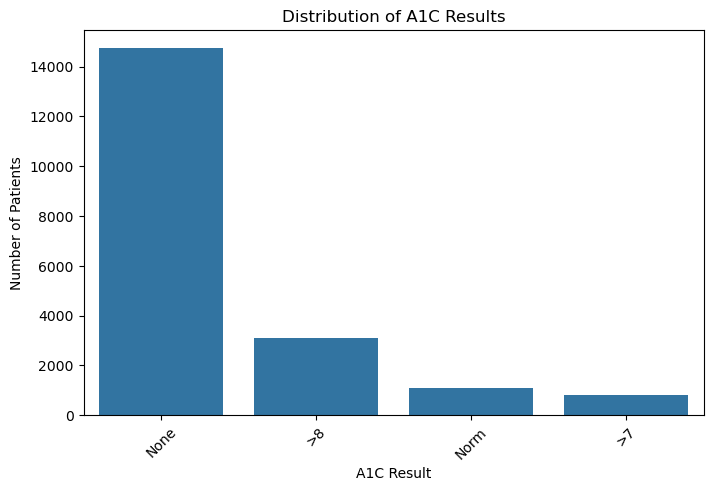

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="a1c_result"
)

plt.title("Distribution of A1C Results")
plt.xlabel("A1C Result")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

### Distribution of maximum glucose serum results

In [64]:
df["max_glu_serum"].value_counts()

max_glu_serum
None    19344
>300      177
Norm      116
>200       52
Name: count, dtype: int64

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="max_glu_serum"
)

plt.title("Distribution of Maximum Glucose Serum Results")
plt.xlabel("Maximum Glucose Serum")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

### Distribution of Insulin

In [65]:
df["insulin"].value_counts()

insulin
No        7878
Steady    6416
Down      2915
Up        2480
Name: count, dtype: int64

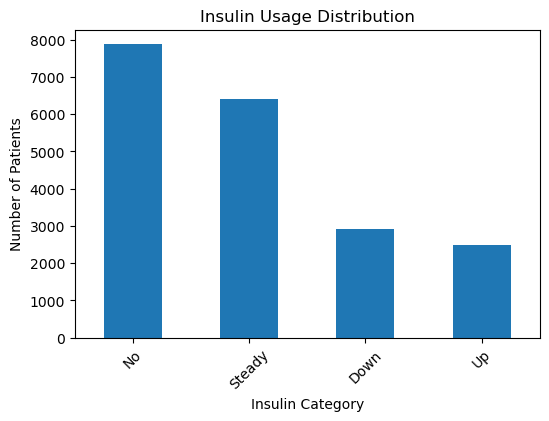

In [66]:
df["insulin"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Insulin Usage Distribution")
plt.xlabel("Insulin Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

# Stratify diabetes management indicators by readmission outcome

In [67]:
df_grouped = (
    df.groupby(["insulin", "a1c_result", "max_glu_serum"])
      .size()
      .reset_index(name="total_test")
      .sort_values("total_test", ascending=False)
      .reset_index(drop=True)
)

df_grouped.head(10)

,insulin,a1c_result,max_glu_serum,total_test
0,No,None,None,6127
1,Steady,None,None,4624
2,Down,None,None,2003
3,Up,None,None,1671
4,Steady,>8,None,1115
5,No,>8,None,759
6,Down,>8,None,598
7,Up,>8,None,588
8,No,Norm,None,450
9,No,>7,None,360


### Clinical Feature Exploration and Interpretation

The distributions of **A1C results, maximum glucose measurements, and insulin use** were reviewed to understand diabetes management patterns and available clinical indicators within the diabetic inpatient cohort.

A large proportion of encounters did not have recorded **A1C or maximum glucose measurements**, with `None` representing missing clinical values. Among encounters with available A1C results, elevated values (**>7 and >8**) were observed in a subset of encounters, indicating that some patients had evidence of elevated blood glucose control markers.

Maximum glucose measurements showed a similar pattern, with most encounters lacking recorded glucose values, while a smaller number of encounters had elevated glucose measurements.

**Insulin usage patterns showed that most encounters involved patients who were either not receiving insulin therapy (7,878 encounters) or were on a steady insulin regimen (6,416 encounters).** A smaller proportion of encounters involved insulin adjustments, including dose increases (**2,480 encounters**) and decreases (**2,915 encounters**).

Clinical feature stratification showed that the most common combinations involved missing laboratory measurements, while elevated A1C categories were observed across different insulin treatment groups.

These clinical characteristics provide insight into **diabetes management patterns, glycemic control indicators, and treatment changes** within the cohort and may contribute to understanding factors associated with **30-day readmission outcomes**.

# Part 7. Outcome Definition and Class Distribution

The original readmission outcome variable (`readmitted`) contained three categories:

- **NO:** No readmission within 30 days
- **>30:** Readmission occurring after 30 days
- **<30:** Readmission occurring within 30 days

For this machine learning task, the outcome was transformed into a binary classification target (`readmission_flag`) focused on predicting **early hospital readmission risk**.

Patients with a readmission within 30 days were classified as positive cases:

- **Readmission within 30 days (<30) = 1**
- **No 30-day readmission (NO or >30) = 0**

This transformation converts the problem into a **binary classification task** by focusing on identifying patients at risk for early readmission.

Before developing predictive models, the distribution of the target variable was evaluated to assess **class balance**. In this cohort of emergency diabetes-related hospital encounters, **30-day readmissions represented the minority class**, while most patients did not experience early readmission.

Because healthcare prediction problems often contain imbalanced outcomes, model performance was evaluated using metrics beyond accuracy, including **precision, recall, F1-score, and ROC-AUC**.

In [68]:
df["readmitted"].value_counts()

readmitted
NO     10518
>30     6940
<30     2231
Name: count, dtype: int64

## Binary Outcome Transformation

For the machine learning task, the original three-class readmission outcome was converted into a binary classification target.

Patients with a readmission within 30 days were classified as positive cases:

- Readmission within 30 days (<30) = 1
- No readmission within 30 days (NO or >30) = 0

This transformation allows the model to focus on predicting early hospital readmission risk, which is clinically important for identifying patients who may benefit from additional intervention.

In [69]:
df["readmission_flag"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

### Verify New Target Variable

In [70]:
df["readmission_flag"].value_counts()

readmission_flag
0    17458
1     2231
Name: count, dtype: int64

## Readmission Outcome Distribution

In [71]:
df["readmission_flag"].value_counts(normalize=True).mul(100).round(2)

readmission_flag
0    88.67
1    11.33
Name: proportion, dtype: float64

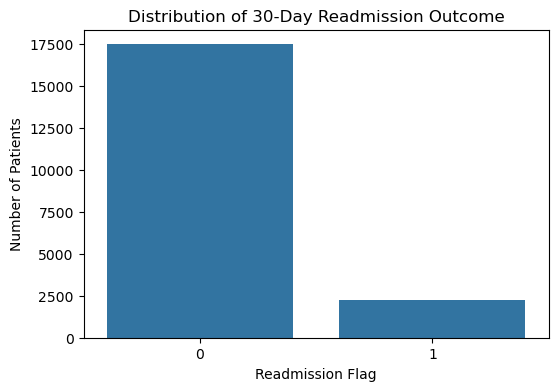

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="readmission_flag"
)

plt.title("Distribution of 30-Day Readmission Outcome")
plt.xlabel("Readmission Flag")
plt.ylabel("Number of Patients")

plt.show()

## Outcome Distribution Interpretation

The original readmission outcome contained three categories:

- No readmission (NO): 10,518 encounters
- Readmission after 30 days (>30): 6,940 encounters
- Readmission within 30 days (<30): 2,231 encounters

For machine learning, the original outcome was transformed into a binary classification target (`readmission_flag`), where encounters with readmission within 30 days were labeled as positive cases (1), and all other encounters were labeled as negative cases (0).

After transformation:

- No 30-day readmission (0): **17,458 encounters (88.67%)**
- 30-day readmission (1): **2,231 encounters (11.33%)**

**The target variable demonstrates class imbalance, with 30-day readmissions representing a smaller proportion of hospital encounters.** This reflects a common challenge in healthcare prediction tasks, where clinically important events occur less frequently than routine outcomes.

Due to this imbalance, machine learning models will be evaluated using metrics that better assess minority class performance, including **precision, recall, F1-score, and ROC-AUC**, rather than accuracy alone.

# Part 8. Readmission Risk Analysis

This section evaluates factors associated with 30-day hospital readmission.

Potential risk factors are examined across three categories:

- Demographic characteristics
- Healthcare utilization patterns
- Clinical diabetes-related factors

The purpose of this analysis is to identify patterns associated with readmission risk and guide feature selection for predictive modeling.

## 8.1 Demographics vs Readmission

Demographic characteristics were evaluated to determine whether patient-level factors were associated with differences in 30-day readmission rates.

The following variables were examined:

- Age
- Gender
- Race

### Readmission rates by age group

In [73]:
pd.crosstab(
    df["age"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
age,,
5,99.047619,0.952381
15,94.272076,5.727924
25,83.228247,16.771753
35,87.331918,12.668082
45,89.023967,10.976033
55,91.141219,8.858781
65,89.039978,10.960022
75,86.792949,13.207051
85,87.779182,12.220818


### Readmission rates by gender

In [74]:
pd.crosstab(
    df["gender"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
gender,,
Female,88.053015,11.946985
Male,89.403900,10.596100


### Readmission rates by race

In [75]:
pd.crosstab(
    df["race"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
race,,
Asian,90.588235,9.411765
Black,88.685185,11.314815
Hispanic,91.071429,8.928571
Other,91.764706,8.235294
Unknown,92.731830,7.268170
White,88.383453,11.616547


## Demographic Characteristics and Readmission Outcome Analysis

Readmission rates were compared across demographic groups to evaluate differences in **30-day readmission patterns** within the inpatient cohort.

Across age groups, the proportion of 30-day readmissions varied. The highest observed readmission rate was among the **25-year age group (16.8%)**, while most age categories showed readmission rates between approximately **9–13%**. These differences suggest that age groups had some variation in readmission patterns, but age alone may not fully explain readmission outcomes.

Gender differences were minimal, with **female encounters showing a slightly higher 30-day readmission rate (11.9%) compared with male encounters (10.6%)**.

Race-based comparisons also showed relatively small differences. **White encounters had a 30-day readmission rate of approximately 11.6%, Black encounters 11.3%, Asian encounters 9.4%, and other racial groups showed similar rates.**

Overall, demographic characteristics showed limited differences in 30-day readmission rates. These variables may provide important patient population context but are unlikely to be strong standalone predictors. Additional clinical and healthcare utilization factors may provide stronger predictive information when combined during machine learning modeling.

## 8.2 Hospital Utilization vs Readmission

Previous healthcare utilization is an important predictor of future hospital readmission.

This section evaluates utilization-related variables including:

- Prior hospital visits
- Emergency visits
- Length of hospital stay

These variables may capture disease complexity, healthcare needs, and patterns associated with increased readmission risk.

### Length of Stay vs Readmission

In [76]:
df.groupby("readmission_flag")["time_in_hospital"].mean()

readmission_flag
0    3.822660
1    4.393545
Name: time_in_hospital, dtype: float64

### Total Number of Inpatient Visits Per Patient vs Readmission

In [77]:
df.groupby("readmission_flag")[
    "number_inpatient_visits"
].agg(["mean", "median", "min", "max"])

,mean,median,min,max
readmission_flag,,,,
0,0.576641,0.0,0,19
1,1.446437,1.0,0,21


### Observed Inpatient Encounters vs Readmission Rate

In [78]:
df.groupby("number_inpatient_visits")["readmission_flag"].mean().mul(100).round(2)

number_inpatient_visits
0       8.21
1      13.50
2      17.77
3      19.97
4      25.79
5      32.24
6      38.21
7      31.17
8      40.00
9      44.44
10     50.00
11     75.00
12     46.67
13     50.00
14     50.00
15    100.00
16     50.00
19      0.00
21    100.00
Name: readmission_flag, dtype: float64

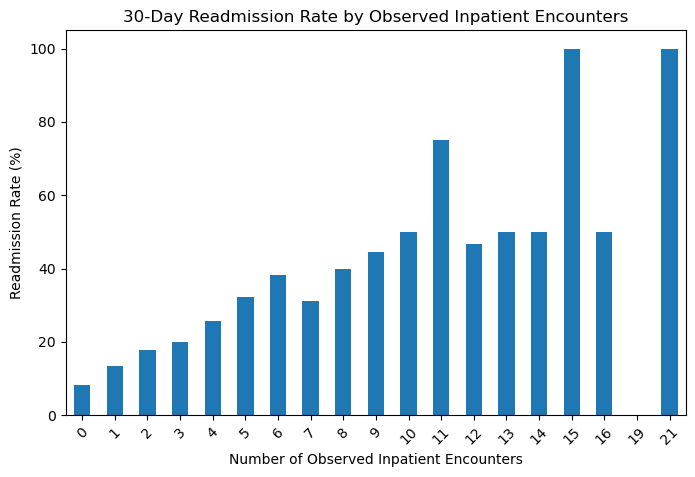

In [79]:
plt.figure(figsize=(8,5))

(
    df.groupby("number_inpatient_visits")["readmission_flag"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("30-Day Readmission Rate by Observed Inpatient Encounters")
plt.xlabel("Number of Observed Inpatient Encounters")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Hospitalization Characteristics and Readmission Outcome Analysis

Hospitalization characteristics and healthcare utilization patterns were evaluated to examine differences between encounters with and without 30-day readmission.

**Length of Stay:**

Average hospital stay duration was compared between readmitted and non-readmitted encounters.

- No 30-day readmission (0): **3.82 days**
- 30-day readmission (1): **4.39 days**

Readmitted encounters had a slightly longer average length of stay, indicating that readmitted encounters in this cohort were associated with somewhat longer hospital stays.

**Observed Inpatient Encounters per Patient:**

The distribution of observed inpatient encounters per patient was compared between readmitted and non-readmitted encounters.

- No 30-day readmission (0): **1.51 average observed encounters**
- 30-day readmission (1): **2.81 average observed encounters**

Readmitted encounters were associated with a higher average number of observed inpatient encounters per patient. The median was also higher among readmitted encounters (**2 vs. 1**).

Because encounter timestamps were not available to establish whether these encounters occurred before or after the current hospitalization, these values represent **observed encounters within the study cohort rather than confirmed prior inpatient visits**.

**Observed Inpatient Encounters and Readmission Rate:**

Readmission rates were evaluated across different values of `number_inpatient_visits`.

The observed readmission rate generally increased across several higher-utilization groups. For example, the readmission rate was **7.27%** among encounters associated with patients having one observed inpatient encounter and **22.39%** among those with three observed encounters.

Some higher-utilization groups had relatively few observations, so their percentages should be interpreted cautiously.

Overall, the analysis identified a relationship between observed inpatient utilization and 30-day readmission outcomes. `number_inpatient_visits` was therefore retained as a utilization feature for predictive modeling, while avoiding interpretation of the variable as confirmed prior utilization.

## 8.3 Clinical Factors vs Readmisssion

Clinical diabetes-related variables were evaluated to determine whether indicators of disease management and treatment complexity were associated with 30-day readmission.

The following features were examined:

- A1C results
- Maximum glucose serum measurements
- Insulin therapy
- Medication changes

### A1C Readmission vs Readmission

In [80]:
pd.crosstab(
    df["a1c_result"],
    df["readmission_flag"],
    normalize="index"
) * 100
    

readmission_flag,0,1
a1c_result,,
>7,88.931298,11.068702
>8,90.847348,9.152652
None,88.063246,11.936754
Norm,90.511628,9.488372


 ### Glucose vs Readmission

In [81]:
pd.crosstab(
    df["max_glu_serum"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
max_glu_serum,,
>200,84.615385,15.384615
>300,84.745763,15.254237
None,88.730356,11.269644
Norm,86.206897,13.793103


### Insulin vs Readmission

In [82]:
pd.crosstab(
    df["insulin"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
insulin,,
Down,85.591767,14.408233
No,89.642041,10.357959
Steady,89.339152,10.660848
Up,87.459677,12.540323


### Medication Change vs Readmission

In [83]:
pd.crosstab(

    df["change_medication"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
change_medication,,
Ch,88.295709,11.704291
No,89.041096,10.958904


## Clinical Risk Factors Interpretation

Clinical variables related to diabetes management and treatment patterns were evaluated to examine differences in 30-day readmission outcomes.

### Glycemic Control Indicators

A1C results showed relatively small differences in observed readmission rates across categories. Encounters without a recorded A1C value had the highest observed readmission rate (**11.94%**), while encounters with documented A1C values showed similar readmission patterns. Overall, A1C category alone showed limited differences in 30-day readmission rates.

Maximum glucose serum measurements demonstrated higher observed readmission rates among encounters with elevated glucose values. Encounters with glucose levels **greater than 200 mg/dL (15.38%)** and **greater than 300 mg/dL (15.25%)** showed higher readmission rates compared with encounters without recorded glucose measurements (**11.27%**). These findings suggest that elevated glucose measurements may provide additional clinical context; however, glucose levels alone may not fully explain readmission outcomes.

### Medication-Related Factors

Insulin treatment categories showed differences in observed readmission rates. Encounters with insulin dosage decreases (**"Down"**) had the highest observed readmission rate (**14.41%**), followed by insulin increases (**"Up"**) (**12.54%**). Encounters with no insulin therapy had a lower observed readmission rate (**10.36%**).

These patterns may reflect differences in diabetes severity, treatment adjustments, or clinical management needs rather than insulin use alone being responsible for readmission risk.

Medication changes also showed small differences in readmission rates. Encounters with medication changes (**"Ch"**) had a slightly higher readmission rate (**11.70%**) compared with encounters without medication changes (**10.96%**). This suggests medication changes may provide additional information about treatment complexity but may have limited predictive value when evaluated independently.

### Clinical Insight

Overall, diabetes management indicators showed modest differences in 30-day readmission outcomes. Glycemic measurements, insulin treatment patterns, and medication changes may capture aspects of disease management and clinical complexity.

Although individual clinical variables demonstrated limited differences when analyzed separately, they may provide additional predictive value when combined with demographic characteristics, hospitalization factors, and healthcare utilization features during machine learning modeling.

# Part 9: Feature Engineering / ML Dataset Preparation

To improve predictive performance, additional features were created to represent healthcare utilization, clinical complexity, and hospitalization intensity.

The engineered features include:

* **Total acute-care visits:** combined inpatient and emergency visits.
* **Diagnoses per day:** number of diagnoses relative to length of stay.
* **Medications per day:** number of medications relative to length of stay.
* **Laboratory procedures per day:** number of laboratory procedures relative to length of stay.

These features were designed to provide the models with additional information about patient healthcare utilization and clinical complexity.

`discharge_disposition_id` was excluded from the predictive feature set because discharge disposition may contain information determined later in the hospitalization and could introduce information leakage depending on the intended prediction time point.


In [84]:
df["diagnoses_per_day"] = (
    df["number_diagnoses"] /
    df["time_in_hospital"].replace(0, 1)
)

df["medications_per_day"] = (
    df["number_medications"] /
    df["time_in_hospital"].replace(0, 1)
)

df["labs_per_day"] = (
    df["number_lab_procedures"] /
    df["time_in_hospital"].replace(0, 1)
)

In [85]:
df[
    [
        "diagnoses_per_day",
        "medications_per_day",
        "labs_per_day"
    ]
].head(10)

,diagnoses_per_day,medications_per_day,labs_per_day
0,5.000000,8.000000,51.000000
1,1.000000,1.888889,5.222222
2,1.142857,2.142857,8.571429
3,1.600000,2.400000,14.600000
4,3.000000,6.500000,5.500000
5,1.000000,3.666667,9.666667
6,3.000000,6.000000,19.666667
7,3.000000,7.000000,33.000000
8,1.500000,5.500000,12.500000
9,1.500000,3.000000,14.500000


### Verify utilization features

In [86]:
df[
    [
        "diagnoses_per_day",
        "medications_per_day",
        "labs_per_day"
    ]
].head(10)

,diagnoses_per_day,medications_per_day,labs_per_day
0,5.000000,8.000000,51.000000
1,1.000000,1.888889,5.222222
2,1.142857,2.142857,8.571429
3,1.600000,2.400000,14.600000
4,3.000000,6.500000,5.500000
5,1.000000,3.666667,9.666667
6,3.000000,6.000000,19.666667
7,3.000000,7.000000,33.000000
8,1.500000,5.500000,12.500000
9,1.500000,3.000000,14.500000


### Check data types

In [87]:
df[
    [
        "diagnoses_per_day",
        "medications_per_day",
        "labs_per_day"
    ]
].dtypes

diagnoses_per_day      float64
medications_per_day    float64
labs_per_day           float64
dtype: object

### Summary Statistics

In [88]:
df[
    [
        "diagnoses_per_day",
        "medications_per_day",
        "labs_per_day"
    ]
].describe()

,diagnoses_per_day,medications_per_day,labs_per_day
count,19689.000000,19689.000000,19689.000000
mean,2.583750,4.785512,17.414237
std,1.979892,3.354051,13.332180
min,0.142857,0.166667,0.090909
25%,1.250000,2.500000,8.333333
50%,2.000000,4.000000,13.666667
75%,3.000000,6.000000,22.000000
max,9.000000,41.000000,97.000000


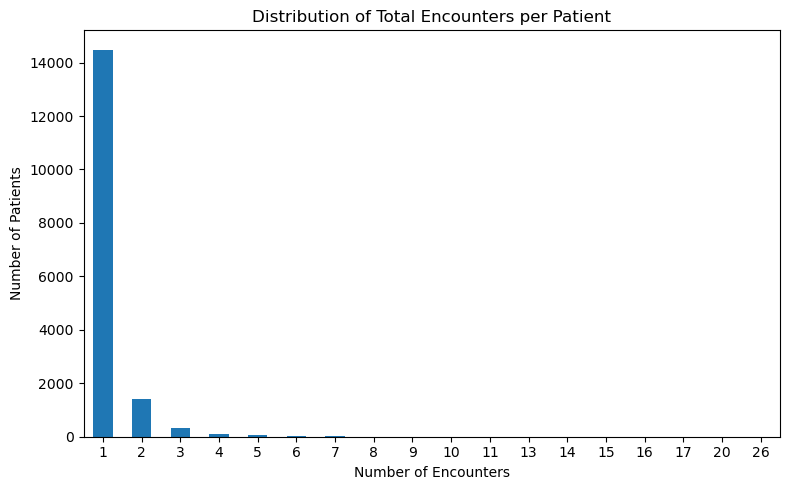

In [89]:
plt.figure(figsize=(8, 5))

encounter_count_distribution.plot(
    kind="bar"
)

plt.title("Distribution of Total Encounters per Patient")
plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Verify the utilization features

In [90]:
df[
    [
        "patient_nbr",
        "number_emergency"
    ]
].head()

,patient_nbr,number_emergency
0,42519267,0
1,89869032,0
2,85504905,1
3,114882984,0
4,86047875,0


## Define the ML features

In [91]:
ml_features = [
    "age",
    "number_emergency",
    "time_in_hospital",
    "number_diagnoses",
    "number_medications",
    "medications_per_day",
    "number_lab_procedures",
    "labs_per_day",
    "diagnoses_per_day",
    "a1c_result",
    "max_glu_serum",
    "insulin",
    "change_medication"
]

### One-hot encode categorical features

In [124]:

X = df[ml_features].copy()


y = df["readmission_flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19689, 13)
y shape: (19689,)


In [125]:
X = pd.get_dummies(
    X,
    columns=[
        "a1c_result",
        "max_glu_serum",
        "insulin",
        "change_medication"
    ],
    drop_first=False
)

print("X shape after encoding:", X.shape)
print("Object columns:", X.select_dtypes(include="object").columns.tolist())

X shape after encoding: (19689, 23)
Object columns: []


### Validate the ML dataset

In [126]:
print("Missing values:", X.isna().sum().sum())

print("\nData types:")
print(X.dtypes)

print("\nObject columns:")
print(X.select_dtypes(include="object").columns.tolist())

Missing values: 0

Data types:
age                        int64
number_emergency           int64
time_in_hospital           int64
number_diagnoses           int64
number_medications         int64
medications_per_day      float64
number_lab_procedures      int64
labs_per_day             float64
diagnoses_per_day        float64
a1c_result_>7               bool
a1c_result_>8               bool
a1c_result_None             bool
a1c_result_Norm             bool
max_glu_serum_>200          bool
max_glu_serum_>300          bool
max_glu_serum_None          bool
max_glu_serum_Norm          bool
insulin_Down                bool
insulin_No                  bool
insulin_Steady              bool
insulin_Up                  bool
change_medication_Ch        bool
change_medication_No        bool
dtype: object

Object columns:
[]


In [127]:
ml_dataset = X.copy()

ml_dataset["readmission_flag"] = y

ml_dataset.to_csv(
    "diabetes_final_ml_dataset.csv",
    index=False
)

## Final Machine Learning Dataset

The final machine-learning dataset contains **19,689 encounter-level observations** and includes clinical, medication, laboratory, and healthcare utilization features selected for predicting 30-day readmission.

The target variable is `readmission_flag`, where:

- `0` = no 30-day readmission
- `1` = 30-day readmission

Before modeling, categorical clinical variables were one-hot encoded and the final feature matrix was validated for missing values and remaining categorical/object columns. The resulting feature matrix contained **23 predictors**, with **0 missing values** and **no remaining object columns**.

The target distribution was imbalanced:

- **17,458 (88.67%)** = no 30-day readmission
- **2,231 (11.33%)** = 30-day readmission

The final feature set excludes `number_inpatient_visits` and `total_acute_visits` because the encounter-count calculation used information from the complete dataset and could introduce temporal leakage. The encounter-count analysis was therefore retained for EDA only.

The final feature set also excludes `discharge_disposition_id` to reduce the potential for information leakage and maintain a more appropriate prediction framework.

## Saving the Final Machine Learning Dataset

The validated machine-learning dataset was saved as `diabetes_final_ml_dataset.csv` to preserve the exact data structure used during model development.

Saving the final ML dataset improves reproducibility and allows the modeling workflow to be recreated or extended in future analyses.

# Part 10: Machine Learning Modeling

After completing data cleaning, feature engineering, exploratory analysis, and preparation of the final machine-learning dataset, supervised classification models were developed to predict **30-day hospital readmission among diabetic inpatient encounters following emergency admission**.

The modeling workflow compares multiple classification algorithms to determine which model provides the strongest balance between identifying readmission cases and maintaining interpretable and reliable predictions.

Because the target outcome is imbalanced, model performance was evaluated using metrics that provide greater insight into the identification of 30-day readmission cases:

- **Precision** — proportion of predicted readmissions that were actual readmissions.
- **Recall** — proportion of actual readmissions correctly identified by the model.
- **F1-score** — balance between precision and recall.
- **ROC-AUC** — ability of the model to distinguish between readmission and non-readmission encounters across classification thresholds.
- **PR-AUC** — performance in identifying the minority readmission class under class imbalance.

Accuracy was also reported, but it was not used as the primary measure of model effectiveness because the majority class represents most encounters in the dataset.

The models were first evaluated using baseline configurations and subsequently evaluated using tuned configurations. Final model selection considered predictive performance, the project's emphasis on identifying readmission cases, and model interpretability.

## 10.1 Training and Testing Dataset Split

The dataset was divided into training and testing subsets using an 80/20 split. Stratification was applied to preserve the proportion of readmission and non-readmission cases in both subsets.

The training dataset was used for model development, cross-validation, and hyperparameter tuning. The test dataset was held out and used only for final model evaluation.


In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15751, 23)
X_test: (3938, 23)
y_train: (15751,)
y_test: (3938,)


### Verify Predictor List

In [129]:
print(X.columns.tolist())

['age', 'number_emergency', 'time_in_hospital', 'number_diagnoses', 'number_medications', 'medications_per_day', 'number_lab_procedures', 'labs_per_day', 'diagnoses_per_day', 'a1c_result_>7', 'a1c_result_>8', 'a1c_result_None', 'a1c_result_Norm', 'max_glu_serum_>200', 'max_glu_serum_>300', 'max_glu_serum_None', 'max_glu_serum_Norm', 'insulin_Down', 'insulin_No', 'insulin_Steady', 'insulin_Up', 'change_medication_Ch', 'change_medication_No']


### Verify Class Imbalance

In [130]:
print("Training target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training target distribution:
readmission_flag
0    13966
1     1785
Name: count, dtype: int64
readmission_flag
0    0.886674
1    0.113326
Name: proportion, dtype: float64

Test target distribution:
readmission_flag
0    3492
1     446
Name: count, dtype: int64
readmission_flag
0    0.886745
1    0.113255
Name: proportion, dtype: float64


## Training and Testing Dataset Validation

The dataset was split into training and testing subsets while maintaining the original class distribution through stratified sampling.

The training dataset contained **15,751 encounters**, while the testing dataset contained **3,938 encounters**. Both datasets maintained a similar proportion of readmitted and non-readmitted cases:

- Non-readmitted encounters: **approximately 88.7%**
- 30-day readmission encounters: **approximately 11.3%**

Maintaining consistent class distribution between the training and testing datasets helps ensure that model evaluation reflects real-world performance and reduces bias caused by an uneven split of the target outcome.

## Baseline Model Development

Three supervised classification models were developed as baseline models to predict **30-day readmission risk among diabetic inpatient encounters following emergency admission**.

The models were selected to compare different approaches for identifying higher-risk inpatient encounters:

- **Logistic Regression**
  - A statistical classification model used to estimate the probability of 30-day readmission.
  - Selected because it is interpretable and provides insight into how demographic, clinical, healthcare utilization features are associated with readmission risk.

- **Random Forest**
  - A machine learning classification model that combines multiple decision trees to make predictions.
  - Selected because it can capture nonlinear relationships and interactions among clinical and healthcare utilization features.

- **XGBoost**
  - A gradient boosting algorithm that builds decision trees sequentially to improve predictive performance.
  - Selected because it is effective for structured/tabular data and can capture complex patterns associated with readmission risk.

These baseline models were evaluated using **precision, recall, F1-score, ROC-AUC, and PR-AUC**. These metrics were emphasized because the readmission outcome was imbalanced, with substantially fewer 30-day readmission encounters than non-readmission encounters.

### Logistic Regression Baseline

In [131]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [132]:
log_predictions = log_model.predict(X_test)
log_probabilities = log_model.predict_proba(X_test)[:, 1]

In [133]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, log_predictions))
print("Precision:", precision_score(y_test, log_predictions))
print("Recall:", recall_score(y_test, log_predictions))
print("F1:", f1_score(y_test, log_predictions))
print("ROC-AUC:", roc_auc_score(y_test, log_probabilities))
print("PR-AUC:", average_precision_score(y_test, log_probabilities))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

Accuracy: 0.6053834433722702
Precision: 0.15717821782178218
Recall: 0.5695067264573991
F1: 0.2463627546071775
ROC-AUC: 0.6254799567493156
PR-AUC: 0.17495390880431713

Confusion Matrix:
[[2130 1362]
 [ 192  254]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.61      0.73      3492
           1       0.16      0.57      0.25       446

    accuracy                           0.61      3938
   macro avg       0.54      0.59      0.49      3938
weighted avg       0.83      0.61      0.68      3938



### Random Forest Baseline

In [134]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_baseline.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [135]:
y_pred_rf_baseline = rf_baseline.predict(X_test)

y_prob_rf_baseline = rf_baseline.predict_proba(X_test)[:, 1]

In [136]:
print("Original Random Forest Results")
print("------------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_rf_baseline))
print("Precision:", precision_score(y_test, y_pred_rf_baseline))
print("Recall:", recall_score(y_test, y_pred_rf_baseline))
print("F1:", f1_score(y_test, y_pred_rf_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_baseline))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf_baseline))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_baseline))

Original Random Forest Results
------------------------------
Accuracy: 0.882935500253936
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5547433210567139
PR-AUC: 0.12811061951108585

Confusion Matrix:
[[3477   15]
 [ 446    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3492
           1       0.00      0.00      0.00       446

    accuracy                           0.88      3938
   macro avg       0.44      0.50      0.47      3938
weighted avg       0.79      0.88      0.83      3938



### XGBoost Baseline

In [137]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=7.8
)

xgb_baseline.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [138]:
y_pred_xgb_baseline = xgb_baseline.predict(X_test)

y_prob_xgb_baseline = xgb_baseline.predict_proba(X_test)[:, 1]

In [139]:
print("Original XGBoost Results")
print("-----------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_baseline))
print("Precision:", precision_score(y_test, y_pred_xgb_baseline))
print("Recall:", recall_score(y_test, y_pred_xgb_baseline))
print("F1:", f1_score(y_test, y_pred_xgb_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_baseline))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb_baseline))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_baseline))

Original XGBoost Results
-----------------------
Accuracy: 0.7331132554596241
Precision: 0.15664018161180476
Recall: 0.3094170403587444
F1: 0.2079879427279578
ROC-AUC: 0.560792702345913
PR-AUC: 0.13727692912721878

Confusion Matrix:
[[2749  743]
 [ 308  138]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      3492
           1       0.16      0.31      0.21       446

    accuracy                           0.73      3938
   macro avg       0.53      0.55      0.52      3938
weighted avg       0.82      0.73      0.77      3938



In [140]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Logistic Regression": [
        0.7013712544438802,
        0.20939490445859874,
        0.5896860986547086,
        0.309048178613396,
        0.6976532522768248,
        0.2508343102124468
    ],
    "Random Forest": [
        0.8849669883189436,
        0.3157894736842105,
        0.013452914798206279,
        0.025806451612903226,
        0.6383045937158089,
        0.1820902589539488
    ],
    "XGBoost": [
        0.7595226003047232,
        0.19488428745432398,
        0.35874439461883406,
        0.2525651144435675,
        0.6414970284416912,
        0.17990867026032162
    ]
})

model_comparison

,Metric,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.701371,0.884967,0.759523
1,Precision,0.209395,0.315789,0.194884
2,Recall,0.589686,0.013453,0.358744
3,F1-Score,0.309048,0.025806,0.252565
4,ROC-AUC,0.697653,0.638305,0.641497
5,PR-AUC,0.250834,0.182090,0.179909


## Baseline Model Evaluation

The three baseline classification models were evaluated on the held-out test set to establish a performance benchmark before hyperparameter tuning. Because the readmission outcome was imbalanced, particular emphasis was placed on **recall, F1-score, ROC-AUC, and PR-AUC**, rather than accuracy alone.

### Logistic Regression — Baseline

The baseline Logistic Regression model achieved an accuracy of **0.605**, precision of **0.157**, recall of **0.570**, F1-score of **0.246**, ROC-AUC of **0.625**, and PR-AUC of **0.175**.

The model correctly identified **254 of the 446 readmission encounters**, while **192 readmission encounters were missed**. The model's recall indicates that it identified approximately **57.0% of the actual readmission encounters** in the held-out test set.

The confusion matrix showed **2,130 true negatives**, **1,362 false positives**, **192 false negatives**, and **254 true positives**.

### Random Forest — Baseline

The baseline Random Forest model achieved high accuracy (**0.883**) but failed to identify any of the readmission encounters at the evaluated classification threshold. Its precision, recall, and F1-score for the readmission class were all **0.000**.

The model correctly identified **0 of the 446 readmission encounters**, while **all 446 readmission encounters were missed**. The confusion matrix contained **3,477 true negatives**, **15 false positives**, **446 false negatives**, and **0 true positives**.

Although the model achieved **88.3% accuracy**, its inability to identify any actual readmission encounters demonstrates why accuracy alone is insufficient for evaluating this imbalanced clinical outcome.

The model achieved a ROC-AUC of **0.555** and PR-AUC of **0.128**.

### XGBoost — Baseline

The baseline XGBoost model achieved an accuracy of **0.733**, precision of **0.157**, recall of **0.309**, F1-score of **0.208**, ROC-AUC of **0.561**, and PR-AUC of **0.137**.

The model correctly identified **138 of the 446 readmission encounters**, while **308 readmission encounters were missed**. This resulted in a recall of approximately **30.9%** for the minority readmission class.

The confusion matrix contained **2,749 true negatives**, **743 false positives**, **308 false negatives**, and **138 true positives**.

### Overall Baseline Findings

Overall, **Logistic Regression provided the strongest baseline performance for identifying the minority readmission class** among the three models evaluated.

It achieved the highest recall (**0.570**), highest F1-score (**0.246**), highest ROC-AUC (**0.625**), and highest PR-AUC (**0.175**) among the baseline models.

Random Forest achieved the highest accuracy (**0.883**) but identified **none of the actual readmission encounters**, resulting in a recall and F1-score of **0.000**.

XGBoost performed better than Random Forest in identifying the minority class, with a recall of **0.309** and F1-score of **0.208**, but its performance remained below Logistic Regression.

Because the primary objective of this project is to identify encounters at risk of **30-day hospital readmission**, minority-class recall and F1-score were prioritized over accuracy alone. Based on these baseline results, **Logistic Regression was the strongest baseline candidate for subsequent model optimization and evaluation**.

# Part 11: Hyperparameter Tuning

## Hyperparameter-Tuned Logistic Regression

After establishing the baseline model, hyperparameter tuning was performed to determine whether the performance of Logistic Regression could be improved. A **5-fold cross-validation GridSearchCV** procedure was used to evaluate different combinations of Logistic Regression hyperparameters.

Because the primary objective of the project is to identify patients at risk of **30-day hospital readmission**, **recall** was selected as the optimization metric. This prioritizes the model's ability to correctly identify patients who experienced a readmission.

The Logistic Regression model retained `class_weight="balanced"` to account for the substantial class imbalance in the readmission outcome. The maximum number of iterations was increased to 2,000 to support model convergence during cross-validation.

The hyperparameter search identified the following configuration as the best-performing combination based on cross-validation recall:

* **C:** 0.01
* **Solver:** `lbfgs`
* **Class weight:** `balanced`
* **Maximum iterations:** 2,000
* **Cross-validation:** 5-fold
* **Optimization metric:** Recall

The best cross-validation recall was **0.547**.

The resulting tuned Logistic Regression model was then evaluated on the held-out test set using the same performance metrics established during baseline evaluation. This allows the tuned model to be compared directly with the baseline and with the tuned Random Forest and XGBoost models.


### Parameter grid

In [141]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

### Run GridSearchCV

In [142]:
log_grid = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    param_grid=log_param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


### Best Parameter/Setting

In [143]:
print("Best Logistic Regression parameters:")
print(log_grid.best_params_)

print("\nBest Cross-Validation Recall:")
print(log_grid.best_score_)

Best Logistic Regression parameters:
{'C': 0.01, 'solver': 'liblinear'}

Best Cross-Validation Recall:
0.5473389355742297


### Get tuned model and generate predictions

In [144]:
best_log_model = log_grid.best_estimator_

y_pred_log = best_log_model.predict(X_test)
y_prob_log = best_log_model.predict_proba(X_test)[:, 1]

### Small Verification

In [146]:
print("Model:", type(best_log_model).__name__)
print("Number of predictions:", len(y_pred_log))
print("Number of probabilities:", len(y_prob_log))

Model: LogisticRegression
Number of predictions: 3938
Number of probabilities: 3938


## Hyperparameter Tuning — Random Forest

After establishing the baseline Random Forest model, hyperparameter tuning was performed to identify a configuration that improved the model's ability to distinguish between patients who experienced 30-day readmission and those who did not.

A **3-fold cross-validation GridSearchCV** procedure was used to evaluate combinations of the number of trees, maximum tree depth, minimum samples required at a leaf, and class weighting. For this model, **ROC-AUC** was selected as the optimization metric to evaluate the model's overall ability to discriminate between readmission and non-readmission encounters across classification thresholds.

The hyperparameter search identified the following configuration as the best-performing combination:

- **Number of estimators:** 400
- **Maximum depth:** 10
- **Minimum samples per leaf:** 5
- **Class weight:** `balanced`
- **Cross-validation:** 3-fold
- **Optimization metric:** ROC-AUC

The best cross-validation ROC-AUC was **0.589**.

The tuned Random Forest model was then evaluated on the held-out test set using the same performance metrics used during baseline evaluation. This provides a direct comparison between the baseline and tuned Random Forest models and allows the tuned model to be evaluated alongside the tuned Logistic Regression and XGBoost models.

### Parameter Grid + GridSearchCV

In [147]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 5],
    "class_weight": ["balanced"]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [10, 20], 'min_samples_leaf': [1, 5], 'n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,400


### Best Parameter/Setting

In [148]:
print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 400}

Best CV ROC-AUC:
0.5885157385306395


### Get tuned model + predictions

In [149]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

### Verify

In [150]:
print("Model:", type(best_rf_model).__name__)
print("Number of predictions:", len(y_pred_rf))
print("Number of probabilities:", len(y_prob_rf))

Model: RandomForestClassifier
Number of predictions: 3938
Number of probabilities: 3938


## Hyperparameter Tuning — XGBoost

After establishing the baseline XGBoost model, hyperparameter tuning was performed to identify a configuration that improved the model's ability to distinguish between patients who experienced 30-day readmission and those who did not.

A **3-fold cross-validation GridSearchCV** procedure was used to evaluate combinations of the number of boosting trees, tree depth, learning rate, subsampling, feature sampling, and class weighting. **ROC-AUC** was selected as the optimization metric to evaluate the model's ability to discriminate between readmission and non-readmission encounters across classification thresholds.

Because the baseline XGBoost model used a `scale_pos_weight` of **7.8** to address class imbalance, the tuning grid included **1, 3, 5, and 7.8** as candidate values. This allowed the tuning process to determine whether the original class-weighting strategy remained optimal.

The hyperparameter search identified the following configuration as the best-performing combination:

- **Number of estimators:** 200
- **Maximum depth:** 3
- **Learning rate:** 0.05
- **Subsample:** 0.8
- **Column sampling by tree:** 0.8
- **Scale positive weight:** 1
- **Cross-validation:** 3-fold
- **Optimization metric:** ROC-AUC

The best cross-validation ROC-AUC was **0.701**.

Interestingly, although the baseline model used `scale_pos_weight=7.8`, the hyperparameter search selected **1** as the optimal value based on cross-validated ROC-AUC. This indicates that additional class weighting did not improve the model's overall discrimination under the selected tuning strategy.

The tuned XGBoost model generated **3,938 predictions and 3,938 predicted probabilities** on the held-out test set. The tuned model was subsequently evaluated using the same performance metrics used during baseline evaluation, allowing direct comparison between the baseline and tuned models.

In [151]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "scale_pos_weight": [1, 3, 5, 7.8]
}


xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)


xgb_grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [200, 400], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


### View best settings

In [152]:
print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_grid.best_score_)

Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}

Best CV ROC-AUC:
0.5992558165942655


### Get tuned model + predictions

In [153]:
best_xgb_model = xgb_grid.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

### Verify

In [154]:
print("Model:", type(best_xgb_model).__name__)
print("Number of predictions:", len(y_pred_xgb))
print("Number of probabilities:", len(y_prob_xgb))

Model: XGBClassifier
Number of predictions: 3938
Number of probabilities: 3938


### Calculate Metrics for Each Tune

In [155]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))

In [156]:
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)

evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


Tuned Logistic Regression
----------------------------------------
Accuracy: 0.6053834433722702
Precision: 0.15717821782178218
Recall: 0.5695067264573991
F1: 0.2463627546071775
ROC-AUC: 0.6271827598251479
PR-AUC: 0.17572516094463328

Tuned Random Forest
----------------------------------------
Accuracy: 0.7470797359065515
Precision: 0.16381418092909536
Recall: 0.3004484304932735
F1: 0.2120253164556962
ROC-AUC: 0.6108513886962642
PR-AUC: 0.15705704561653205

Tuned XGBoost
----------------------------------------
Accuracy: 0.8869984763839512
Precision: 1.0
Recall: 0.002242152466367713
F1: 0.0044742729306487695
ROC-AUC: 0.6364833263988412
PR-AUC: 0.17761562538536585


### Overall Tuned Model Findings

The tuned models produced different performance profiles across the evaluation metrics.

Tuned Logistic Regression achieved the highest recall (**0.570**) and highest F1-score (**0.246**) among the three tuned models. Tuned Random Forest achieved a recall of **0.300** and F1-score of **0.212**.

Tuned XGBoost achieved the highest accuracy (**0.887**) and precision (**1.000**), but its recall was only **0.002**, resulting in an F1-score of **0.004**. This indicates that the model identified almost none of the actual readmission encounters at the default classification threshold.

Because the primary objective of the project is to identify encounters at risk of **30-day hospital readmission**, minority-class recall and F1-score remain important considerations when evaluating the tuned models.

These results support carrying **Logistic Regression forward as the leading candidate model** for subsequent probability calibration and classification-threshold analysis. Threshold optimization will be used to determine whether an alternative operating threshold can improve the balance between identifying readmission encounters and limiting false-positive predictions.

## Baseline vs. Tuned Model Comparison

Baseline and tuned model performance were compared to determine whether hyperparameter optimization improved predictive performance.

The comparison focuses on **accuracy, recall, F1-score, and ROC-AUC**. PR-AUC was also considered because of the substantial class imbalance in the readmission outcome.

Overall, hyperparameter tuning produced different effects across the three models. Logistic Regression performance decreased across the primary evaluation metrics, including recall, F1-score, ROC-AUC, and PR-AUC. Random Forest showed a substantial improvement in minority-class recall and F1-score, although its ROC-AUC decreased slightly. XGBoost achieved higher accuracy and precision but very low recall at the evaluated classification threshold.

### Create the Comparison Chart

In [157]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Baseline Accuracy": [
        0.7013712544438802,
        0.8849669883189436,
        0.7595226003047232
    ],

    "Tuned Accuracy": [
        0.6053834433722702,
        0.7470797359065515,
        0.8869984763839512
    ],

    "Baseline Precision": [
        0.209,
        0.0,
        0.15664018161180476
    ],

    "Tuned Precision": [
        0.15717821782178218,
        0.16381418092909536,
        1.0
    ],

    "Baseline Recall": [
        0.5896860986547086,
        0.013452914798206279,
        0.35874439461883406
    ],

    "Tuned Recall": [
        0.5695067264573991,
        0.3004484304932735,
        0.002242152466367713
    ],

    "Baseline F1": [
        0.309048178613396,
        0.025806451612903226,
        0.2525651144435675
    ],

    "Tuned F1": [
        0.2463627546071775,
        0.2120253164556962,
        0.0044742729306487695
    ],

    "Baseline ROC-AUC": [
        0.6976532522768248,
        0.6383045937158089,
        0.6414970284416912
    ],

    "Tuned ROC-AUC": [
        0.6271827598251479,
        0.6108513886962642,
        0.6364833263988412
    ]
})

comparison

,Model,Baseline Accuracy,Tuned Accuracy,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC
0,Logistic Regression,0.701371,0.605383,0.20900,0.157178,0.589686,0.569507,0.309048,0.246363,0.697653,0.627183
1,Random Forest,0.884967,0.747080,0.00000,0.163814,0.013453,0.300448,0.025806,0.212025,0.638305,0.610851
2,XGBoost,0.759523,0.886998,0.15664,1.000000,0.358744,0.002242,0.252565,0.004474,0.641497,0.636483


### Calculate the changes

In [158]:
comparison["Recall Change"] = (
    comparison["Tuned Recall"] -
    comparison["Baseline Recall"]
)

comparison["F1 Change"] = (
    comparison["Tuned F1"] -
    comparison["Baseline F1"]
)

comparison["ROC-AUC Change"] = (
    comparison["Tuned ROC-AUC"] -
    comparison["Baseline ROC-AUC"]
)

comparison.round(3)

,Model,Baseline Accuracy,Tuned Accuracy,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC,Recall Change,F1 Change,ROC-AUC Change
0,Logistic Regression,0.701,0.605,0.209,0.157,0.590,0.570,0.309,0.246,0.698,0.627,-0.020,-0.063,-0.070
1,Random Forest,0.885,0.747,0.000,0.164,0.013,0.300,0.026,0.212,0.638,0.611,0.287,0.186,-0.027
2,XGBoost,0.760,0.887,0.157,1.000,0.359,0.002,0.253,0.004,0.641,0.636,-0.357,-0.248,-0.005


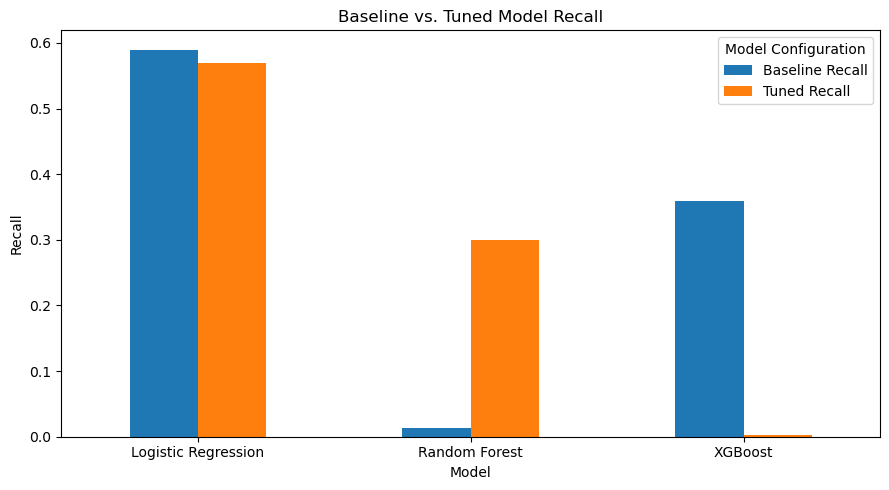

In [159]:
comparison_plot = comparison.set_index("Model")[
    ["Baseline Recall", "Tuned Recall"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs. Tuned Model Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=0)
plt.legend(title="Model Configuration")
plt.tight_layout()
plt.show()

### Overall Findings

The baseline and tuned results demonstrated that hyperparameter optimization did not consistently improve model performance across the three algorithms.

For **Logistic Regression**, tuning resulted in lower accuracy, recall, F1-score, ROC-AUC, and PR-AUC compared with the baseline configuration. Recall decreased from **0.590 to 0.570**, while F1-score decreased from **0.309 to 0.246**.

For **Random Forest**, tuning substantially improved minority-class performance. Recall increased from **0.013 to 0.300**, and F1-score increased from **0.026 to 0.212**. However, accuracy decreased from **0.885 to 0.747**, demonstrating the trade-off between majority-class accuracy and minority-class detection.

For **XGBoost**, tuning increased accuracy from **0.760 to 0.887**, but recall decreased substantially from **0.359 to 0.002**. F1-score also decreased from **0.253 to 0.004**. Although the tuned model achieved very high precision, its extremely low recall limited its usefulness for identifying actual readmission encounters.

Because the primary objective of the project is to identify encounters at risk of **30-day hospital readmission**, minority-class recall and F1-score were prioritized during model selection.

The **baseline Logistic Regression model** therefore remained the strongest candidate for subsequent probability calibration and classification-threshold analysis because it provided the highest recall (**0.590**) and F1-score (**0.309**) among the evaluated baseline and tuned configurations while also maintaining model interpretability.

# Part 12: Final Model Selection

## Calibration

## Probability Calibration

After comparing the baseline and tuned models, the **baseline Logistic Regression model was selected as the final classification model** because it achieved the strongest overall balance of minority-class performance and model discrimination among the evaluated configurations.

Probability calibration was then evaluated as an **additional analysis of the selected Logistic Regression model**. Calibration assesses whether predicted probabilities provide a reliable estimate of observed 30-day readmission risk.

The selected Logistic Regression model was calibrated using **5-fold cross-validation with sigmoid calibration (Platt scaling)**. Calibration was performed using the training data, while the held-out test set was reserved for evaluating the baseline and calibrated probability estimates.

The calibrated model and subsequent threshold optimization were evaluated as an alternative configuration. Although calibration improved probability reliability, the calibrated and threshold-optimized configuration did not outperform the original baseline Logistic Regression on the primary classification metrics. Therefore, the **baseline Logistic Regression with the 0.50 classification threshold remained the final selected model**.

## Logistic Regression Calibration

In [173]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_log_model = CalibratedClassifierCV(
    estimator=log_model,
    method="sigmoid",
    cv=5
)

calibrated_log_model.fit(X_train, y_train)

C:\Users\davon\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimator,LogisticRegre...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


### Calibration Performance

The calibrated model was evaluated using the **Brier score** to assess the reliability of its predicted probabilities.

The Brier score measures the difference between predicted probabilities and the actual observed outcomes. Lower values indicate better probability calibration.

The calibrated model was compared with the original Logistic Regression model to determine whether calibration improved the reliability of the predicted probabilities.

### Generate calibrated probabilities on the test set

In [174]:
calibrated_test_probabilities = calibrated_log_model.predict_proba(
    X_test
)[:, 1]

print(
    "Number of calibrated test probabilities:",
    len(calibrated_test_probabilities)
)

Number of calibrated test probabilities: 3938


### Code — Compare Brier Scores

In [175]:
from sklearn.metrics import brier_score_loss


baseline_test_probabilities = log_model.predict_proba(
    X_test
)[:, 1]


baseline_brier = brier_score_loss(
    y_test,
    baseline_test_probabilities
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_test_probabilities
)

print("Baseline Brier Score:", round(baseline_brier, 4))
print("Calibrated Brier Score:", round(calibrated_brier, 4))

Baseline Brier Score: 0.2376
Calibrated Brier Score: 0.0986


### Calibration Results

Probability calibration was evaluated using the Brier score, which measures the accuracy and reliability of predicted probabilities, with lower values indicating better calibration.

The baseline Logistic Regression model produced a Brier score of **0.2376**, while the calibrated model produced a Brier score of **0.0986**.

The substantial reduction in Brier score indicates that sigmoid calibration improved the reliability of the model's predicted probabilities on the held-out test set.

The calibration curve was then examined to visually compare the baseline and calibrated probability estimates against the ideal calibration line.

### Calibration Curve

A calibration curve was generated to visually compare predicted readmission probabilities with observed readmission frequencies.

A well-calibrated model should produce predicted probabilities that closely correspond to the observed proportion of positive outcomes. The calibration curve provides an additional assessment of probability reliability beyond the Brier score.

### Calibration Curve

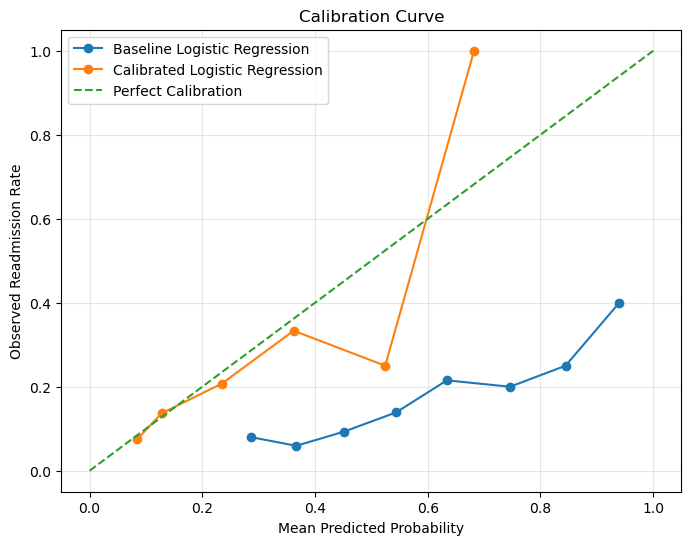

In [185]:
from sklearn.calibration import calibration_curve


baseline_true, baseline_pred = calibration_curve(
    y_test,
    baseline_test_probabilities,
    n_bins=10,
    strategy="uniform"
)


calibrated_true, calibrated_pred = calibration_curve(
    y_test,
    calibrated_test_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_pred,
    baseline_true,
    marker="o",
    label="Baseline Logistic Regression"
)

plt.plot(
    calibrated_pred,
    calibrated_true,
    marker="o",
    label="Calibrated Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Calibration Findings

The baseline Logistic Regression model produced a Brier score of **0.2376**, while the calibrated Logistic Regression model produced a substantially lower Brier score of **0.0986**.

Because a lower Brier score indicates better agreement between predicted probabilities and observed outcomes, the reduction from **0.2376 to 0.0986** indicates that sigmoid calibration substantially improved the reliability of the model's predicted readmission probabilities.

The calibration analysis therefore supports the use of the calibrated model when the primary goal is obtaining more reliable probability estimates. However, improved probability calibration does not necessarily mean improved classification performance. Therefore, classification threshold optimization was performed as the next step to determine whether the calibrated probabilities could improve the model's ability to identify 30-day readmission encounters.

## Classification Threshold Optimization

The default classification threshold of **0.50** was used during the initial evaluation of the baseline Logistic Regression model. Because the primary objective of this project is to identify 30-day readmission encounters, threshold optimization was performed to evaluate whether an alternative probability cutoff could provide a better balance between precision and recall.

Threshold selection was performed using **out-of-fold predicted probabilities generated from the training data**. This approach prevented the held-out test set from influencing threshold selection.

A calibrated Logistic Regression model was evaluated using nested cross-validation. The outer 5-fold cross-validation generated out-of-fold probabilities, while the calibration procedure used 5-fold cross-validation within each training fold.

The test set remained untouched during threshold selection. After the optimal threshold was identified, it was locked and applied once to the held-out test set for final evaluation.

### Generate Out-of-Fold Probabilities

In [177]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict


threshold_base_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

threshold_calibrated_model = CalibratedClassifierCV(
    estimator=threshold_base_model,
    method="sigmoid",
    cv=5
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_calibrated_probabilities = cross_val_predict(
    threshold_calibrated_model,
    X_train,
    y_train,
    cv=outer_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(
    "Number of OOF calibrated probabilities:",
    len(oof_calibrated_probabilities)
)

Number of OOF calibrated probabilities: 15751


### Threshold Search

A range of classification thresholds from **0.05 to 0.90** was evaluated using the out-of-fold calibrated probabilities generated from the training data.

For each threshold, precision, recall, and F1-score were calculated. **F1-score was used as the primary threshold-selection criterion** because it provides a balance between precision and recall in the presence of the imbalanced readmission outcome.

The held-out test set was not used during threshold selection. This prevented information from the test set from influencing the selected operating threshold.

### Find the Optimal Threshold

In [178]:
thresholds = np.arange(0.05, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    oof_predictions = (
        oof_calibrated_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,Threshold,Precision,Recall,F1
0,0.05,0.113369,1.000000,0.203651
1,0.06,0.113734,0.996078,0.204157
2,0.07,0.115344,0.977031,0.206329
3,0.08,0.120017,0.936134,0.212758
4,0.09,0.126457,0.844818,0.219985


### Select Best Threshold

In [179]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Optimal Threshold:", round(best_threshold, 3))
print("OOF Precision:", round(best_threshold_row["Precision"], 3))
print("OOF Recall:", round(best_threshold_row["Recall"], 3))
print("OOF F1:", round(best_threshold_row["F1"], 3))

Optimal Threshold: 0.11
OOF Precision: 0.146
OOF Recall: 0.598
OOF F1: 0.234


## Threshold Optimization Findings

The threshold search identified **0.11** as the optimal operating threshold based on the highest out-of-fold F1-score.

At this threshold, the out-of-fold results were:

- **Precision:** 0.146
- **Recall:** 0.598
- **F1-score:** 0.234

The optimized threshold was substantially lower than the default **0.50** threshold, reflecting the model's imbalanced readmission outcome and the potential benefit of classifying more encounters as positive to identify additional readmission cases.

However, the threshold was selected using out-of-fold training predictions and therefore required evaluation on the untouched held-out test set before determining whether it improved the final model's classification performance.

The selected threshold of **0.11** was therefore locked and subsequently applied to the calibrated test-set probabilities for final evaluation.

## Final Model Evaluation

The optimal classification threshold identified using out-of-fold training predictions was locked before evaluating the held-out test set.

The calibrated Logistic Regression model was then applied to the held-out test set using the selected threshold of **0.11**. The test set was not used during threshold selection, providing an independent evaluation of the calibrated and threshold-optimized configuration.

Performance was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix.

The calibrated and threshold-optimized configuration was subsequently compared with the baseline Logistic Regression model at the default **0.50 threshold**. Although threshold optimization slightly increased recall, the baseline Logistic Regression model provided stronger overall classification performance and was therefore retained as the final classification model.

### Fit the final calibrated model

In [180]:
final_calibrated_log_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    method="sigmoid",
    cv=5
)

final_calibrated_log_model.fit(
    X_train,
    y_train
)

print("Final calibrated Logistic Regression fitted.")

C:\Users\davon\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Final calibrated Logistic Regression fitted.


### Apply the locked threshold to the test set

In [181]:

final_test_probabilities = (
    final_calibrated_log_model
    .predict_proba(X_test)[:, 1]
)


final_test_predictions = (
    final_test_probabilities >= best_threshold
).astype(int)

print("Final test predictions generated.")

Final test predictions generated.


### Final evaluation

In [182]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

final_accuracy = accuracy_score(
    y_test,
    final_test_predictions
)

final_precision = precision_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_test_probabilities
)

final_pr_auc = average_precision_score(
    y_test,
    final_test_probabilities
)

print("## Final Model Results")
print()
print("Threshold:", round(best_threshold, 3))
print("Accuracy:", round(final_accuracy, 3))
print("Precision:", round(final_precision, 3))
print("Recall:", round(final_recall, 3))
print("F1-Score:", round(final_f1, 3))
print("ROC-AUC:", round(final_roc_auc, 3))
print("PR-AUC:", round(final_pr_auc, 3))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_test_predictions,
        zero_division=0
    )
)

## Final Model Results

Threshold: 0.11
Accuracy: 0.566
Precision: 0.149
Recall: 0.603
F1-Score: 0.24
ROC-AUC: 0.626
PR-AUC: 0.175

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.56      0.70      3492
           1       0.15      0.60      0.24       446

    accuracy                           0.57      3938
   macro avg       0.53      0.58      0.47      3938
weighted avg       0.83      0.57      0.64      3938



### Interpretation

The calibrated and threshold-optimized configuration achieved a recall of **0.603** and an F1-score of **0.240** on the held-out test set using the selected threshold of **0.11**.

Although recall increased slightly compared with the baseline Logistic Regression model (**0.603 vs. 0.590**), the calibrated and threshold-optimized configuration produced lower precision (**0.149 vs. 0.209**), F1-score (**0.240 vs. 0.309**), ROC-AUC (**0.626 vs. 0.698**), and PR-AUC (**0.175 vs. 0.251**). Accuracy also decreased from **0.701 to 0.566**.

Therefore, the calibrated and threshold-optimized configuration was **not selected as the final classification model**. The baseline Logistic Regression model with the **0.50 threshold** remained the final selected model because it provided a stronger overall balance of minority-class recall, F1-score, precision, and discrimination.

### Confusion Matrix Chart

In [183]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_test_predictions
)

print(cm)

[[1961 1531]
 [ 177  269]]


### Calibration/threshold summary code

In [184]:
print("Baseline Brier Score:", round(baseline_brier, 4))
print("Calibrated Brier Score:", round(calibrated_brier, 4))

print("Optimal Threshold:", round(best_threshold, 3))
print("OOF Precision:", round(best_threshold_row["Precision"], 3))
print("OOF Recall:", round(best_threshold_row["Recall"], 3))
print("OOF F1:", round(best_threshold_row["F1"], 3))

Baseline Brier Score: 0.2376
Calibrated Brier Score: 0.0986
Optimal Threshold: 0.11
OOF Precision: 0.146
OOF Recall: 0.598
OOF F1: 0.234


## Calibration and Threshold Optimization Findings

Probability calibration substantially improved the reliability of the model's predicted probabilities, with the Brier score decreasing from **0.2376** for the baseline Logistic Regression model to **0.0986** after sigmoid calibration.

Threshold optimization identified **0.11** as the optimal threshold based on the highest out-of-fold F1-score. At this threshold, the out-of-fold precision was **0.146**, recall was **0.598**, and F1-score was **0.234**.

When the calibrated model and selected threshold of **0.11** were evaluated on the held-out test set, the model achieved an accuracy of **0.566**, precision of **0.149**, recall of **0.603**, and F1-score of **0.240**.

Although the calibrated and threshold-optimized configuration slightly improved recall compared with the baseline model (**0.603 vs. 0.590**), it produced lower precision (**0.149 vs. 0.209**), F1-score (**0.240 vs. 0.309**), ROC-AUC (**0.626 vs. 0.698**), PR-AUC (**0.175 vs. 0.251**), and accuracy (**0.566 vs. 0.701**).

Therefore, the **baseline Logistic Regression model with the 0.50 classification threshold was retained as the final classification model**. Probability calibration was retained as an additional analysis because it substantially improved the reliability of the model's predicted probabilities, while threshold optimization demonstrated the trade-off between increasing recall and generating additional false-positive predictions.

### Calibration and Threshold Optimization Limitations

Probability calibration was evaluated for the selected baseline Logistic Regression model.

Calibration substantially improved the Brier score from **0.2376** to **0.0986**, indicating substantially improved reliability of the predicted probabilities.

Threshold optimization identified **0.11** as the optimal threshold based on the highest out-of-fold F1-score. The out-of-fold precision was **0.146**, recall was **0.598**, and F1-score was **0.234**.

When the calibrated and threshold-optimized configuration was evaluated on the held-out test set, it achieved an accuracy of **0.566**, precision of **0.149**, recall of **0.603**, F1-score of **0.240**, ROC-AUC of **0.626**, and PR-AUC of **0.175**.

Although the threshold-optimized configuration slightly increased recall compared with the baseline Logistic Regression model (**0.603 vs. 0.590**), it produced lower precision, F1-score, ROC-AUC, PR-AUC, and accuracy.

Therefore, the calibrated and threshold-optimized configuration was **not selected as the final classification model**. The baseline Logistic Regression model at the **0.50 threshold** was retained because it provided a stronger overall balance of minority-class performance and discrimination.

### Logistic Regression Baseline vs. Tuned Logistic Regression

In [172]:
logistic_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline Logistic Regression": [
        0.701371,
        0.209395,
        0.589686,
        0.309048,
        0.697653
    ],
    "Tuned Logistic Regression": [
        0.605383,
        0.157178,
        0.569507,
        0.246363,
        0.627183
    ]
})

logistic_comparison.round(3)

,Metric,Baseline Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.701,0.605
1,Precision,0.209,0.157
2,Recall,0.590,0.570
3,F1-Score,0.309,0.246
4,ROC-AUC,0.698,0.627


# Part 13: Final Model Interpretation — Logistic Regression

The selected **baseline Logistic Regression model** was interpreted to identify the features most strongly associated with predicted 30-day hospital readmission risk.

Because Logistic Regression provides interpretable coefficients, model coefficients were converted to **odds ratios** to make the direction and magnitude of model-based associations easier to interpret.

- An **odds ratio greater than 1** indicates higher estimated odds of readmission as the feature increases, holding the other model features constant.
- An **odds ratio less than 1** indicates lower estimated odds of readmission.
- An **odds ratio near 1** indicates a relatively small association with the predicted outcome.

Because the categorical variables were one-hot encoded using `drop_first=False`, all available categories were retained as separate indicator variables. Their coefficients and odds ratios should therefore be interpreted cautiously within the context of the complete fitted model rather than as simple comparisons against an omitted reference category.

These coefficients and odds ratios represent **model-based associations rather than causal effects**. They should therefore not be interpreted as evidence that a particular clinical, medication, or healthcare utilization factor directly causes or prevents readmission.

### Create the coefficient + odds-ratio table

In [198]:
feature_names = X_train.columns

coefficients = log_model.coef_[0]

logistic_interpretation = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

logistic_interpretation["Odds_Ratio"] = np.exp(
    logistic_interpretation["Coefficient"]
)

logistic_interpretation = logistic_interpretation.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_table = logistic_interpretation.copy()

coefficient_table["Coefficient"] = (
    coefficient_table["Coefficient"].round(3)
)

coefficient_table["Odds_Ratio"] = (
    coefficient_table["Odds_Ratio"].round(3)
)

coefficient_table

,Feature,Coefficient,Odds_Ratio
1,number_emergency,0.206,1.229
3,number_diagnoses,0.094,1.098
17,insulin_Down,0.082,1.086
11,a1c_result_None,0.057,1.058
2,time_in_hospital,0.038,1.039
5,medications_per_day,0.033,1.034
20,insulin_Up,0.010,1.010
4,number_medications,0.003,1.003
7,labs_per_day,0.002,1.002
0,age,0.002,1.002


### Get the strongest positive and negative coefficients

In [199]:
top_positive = (
    logistic_interpretation
    .sort_values("Coefficient", ascending=False)
    .head(5)
)

top_negative = (
    logistic_interpretation
    .sort_values("Coefficient", ascending=True)
    .head(5)
)

top_coefficients = pd.concat([
    top_positive,
    top_negative
])

top_coefficients["Coefficient"] = (
    top_coefficients["Coefficient"].round(3)
)

top_coefficients["Odds_Ratio"] = (
    top_coefficients["Odds_Ratio"].round(3)
)

top_coefficients

,Feature,Coefficient,Odds_Ratio
1,number_emergency,0.206,1.229
3,number_diagnoses,0.094,1.098
17,insulin_Down,0.082,1.086
11,a1c_result_None,0.057,1.058
2,time_in_hospital,0.038,1.039
21,change_medication_Ch,-0.324,0.723
18,insulin_No,-0.271,0.763
19,insulin_Steady,-0.239,0.788
10,a1c_result_>8,-0.230,0.794
12,a1c_result_Norm,-0.181,0.835


### Visualization — strongest positive and negative coefficients

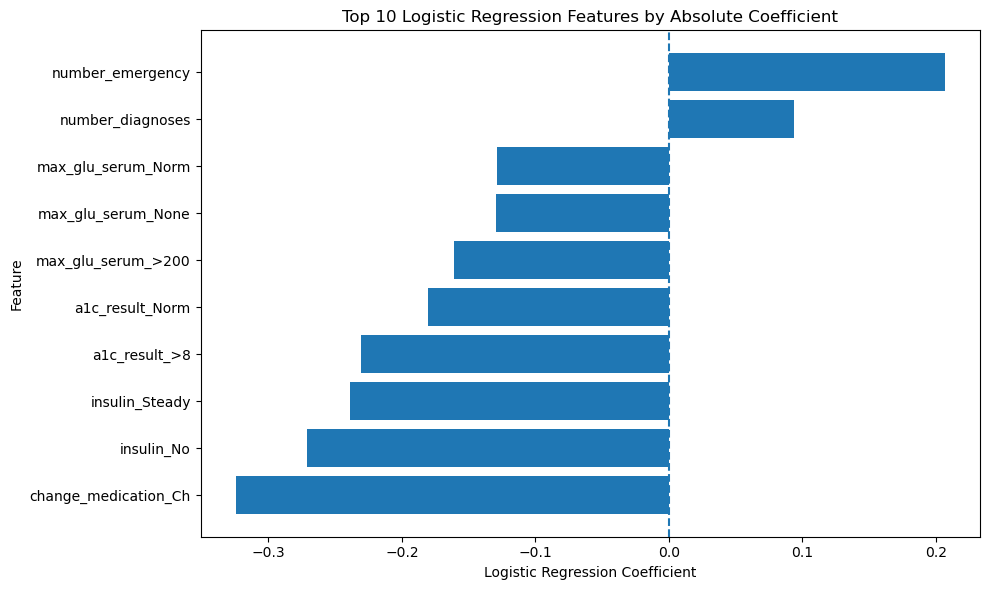

In [200]:
top_features = (
    logistic_interpretation
    .assign(
        Absolute_Coefficient=lambda x: x["Coefficient"].abs()
    )
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top 10 Logistic Regression Features by Absolute Coefficient"
)

plt.tight_layout()
plt.show()

## Logistic Regression Feature Interpretation

The final baseline Logistic Regression model provides interpretable coefficients that can be converted into odds ratios. The odds ratios describe the relative change in the estimated odds of 30-day readmission associated with each feature, holding the other model features constant.

Among the continuous features, **number of emergency visits** had the largest positive coefficient (**0.206**) and an odds ratio of **1.229**. This corresponds to approximately **22.9% higher estimated odds of readmission per one-unit increase in number of emergency visits**, holding the other model features constant.

**Number of diagnoses** also showed a positive association, with an odds ratio of **1.098**, corresponding to approximately **9.8% higher estimated odds of readmission per additional diagnosis**. **Time in hospital** had an odds ratio of **1.039**, corresponding to approximately **3.9% higher estimated odds of readmission per additional hospital day**.

Among the categorical features, `insulin_Down` had a positive coefficient of **0.082** and an odds ratio of **1.086**, while `a1c_result_None` had an odds ratio of **1.058**. These coefficients indicate positive associations with the model's estimated readmission odds within the fitted model.

Several categorical features had negative coefficients and odds ratios below 1. For example, `change_medication_Ch` had an odds ratio of **0.723**, `insulin_No` had an odds ratio of **0.763**, `insulin_Steady` had an odds ratio of **0.788**, and `a1c_result_>8` had an odds ratio of **0.794**. These coefficients indicate lower estimated odds of readmission within the fitted model.

Because the categorical variables were one-hot encoded using `drop_first=False`, all available categories were retained as indicator variables. Their coefficients and odds ratios should therefore be interpreted cautiously within the context of the complete fitted model rather than as simple comparisons against an omitted reference category.

The coefficients represent **model-based associations rather than causal effects**. They do not establish that a particular clinical, medication, or utilization factor directly causes or prevents 30-day readmission.

Overall, the strongest positive associations in the final Logistic Regression model were related to **emergency healthcare utilization, clinical complexity, and hospital length of stay**, particularly number of emergency visits, number of diagnoses, and time in hospital.

# Part 14: Final Model Prediction & Encounter-Level Risk Tracking

### Generate final predictions

In [191]:

final_model_probabilities = (
    log_model.predict_proba(X_test)[:, 1]
)

final_model_predictions = (
    final_model_probabilities >= 0.50
).astype(int)

print("Final probabilities generated:", len(final_model_probabilities))
print("Final predictions generated:", len(final_model_predictions))

Final probabilities generated: 3938
Final predictions generated: 3938


### Build the encounter-level tracking table

In [197]:
prediction_results = df.loc[
    X_test.index,
    ["encounter_id", "patient_nbr"]
].copy()

prediction_results["actual_readmission"] = y_test.values
prediction_results["predicted_probability"] = final_model_probabilities
prediction_results["predicted_readmission"] = final_model_predictions

prediction_results.head(10)

,encounter_id,patient_nbr,actual_readmission,predicted_probability,predicted_readmission
8971,131064366,67687461,0,0.362938,0
12409,172292070,89391123,0,0.517998,1
3045,52801974,18840807,0,0.374185,0
12570,174672978,82256913,0,0.584130,1
10209,149907636,85009266,0,0.381881,0
13689,196709838,95838174,0,0.537962,1
2849,50480016,74290716,0,0.381353,0
8080,114087924,24843753,0,0.623216,1
11545,163414902,88052274,0,0.612241,1
13973,204475932,64462698,0,0.451871,0


### Rank highest-risk encounters

In [195]:
high_risk_encounters = (
    prediction_results
    .sort_values(
        "predicted_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

high_risk_encounters.head(20)

,encounter_id,patient_nbr,actual_readmission,predicted_probability,predicted_readmission
0,224745156,90609804,1,0.969390,1
1,192803478,88227540,0,0.942792,1
2,244252098,4071312,0,0.936420,1
3,172669098,4790016,0,0.925279,1
4,187587870,23718141,1,0.924852,1
5,264482610,85029048,0,0.879093,1
6,390834974,44318196,0,0.849339,1
7,150406968,24767658,1,0.848028,1
8,239681916,41322456,0,0.801388,1
9,165464196,23239827,1,0.798776,1


### Only predicted readmissions -Which encounters did my final model predict would be readmitted?

In [196]:
predicted_readmissions = (
    prediction_results[
        prediction_results["predicted_readmission"] == 1
    ]
    .sort_values(
        "predicted_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

predicted_readmissions.head(20)

,encounter_id,patient_nbr,actual_readmission,predicted_probability,predicted_readmission
0,224745156,90609804,1,0.969390,1
1,192803478,88227540,0,0.942792,1
2,244252098,4071312,0,0.936420,1
3,172669098,4790016,0,0.925279,1
4,187587870,23718141,1,0.924852,1
5,264482610,85029048,0,0.879093,1
6,390834974,44318196,0,0.849339,1
7,150406968,24767658,1,0.848028,1
8,239681916,41322456,0,0.801388,1
9,165464196,23239827,1,0.798776,1


### Save the tracking results

In [194]:
prediction_results.to_csv(
    "diabetes_final_prediction_results.csv",
    index=False
)

print(
    "Saved diabetes_final_prediction_results.csv"
)

Saved diabetes_final_prediction_results.csv


# Part 15: Project Conclusion

## Final Recommendation

The **baseline Logistic Regression model** was selected as the final classification model for predicting 30-day hospital readmission among diabetic inpatient encounters following emergency admission.

Model selection considered accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and model interpretability. Greater emphasis was placed on **recall and F1-score** because 30-day readmission represented the minority class and the primary objective was to identify encounters at higher risk of readmission.

At the default classification threshold of **0.50**, the final baseline Logistic Regression model achieved:

- **Accuracy:** 0.701
- **Precision:** 0.209
- **Recall:** 0.590
- **F1-score:** 0.309
- **ROC-AUC:** 0.698
- **PR-AUC:** 0.251

The model correctly identified **263 of the 446 actual 30-day readmission encounters**, while **183 readmission encounters were missed**. It also correctly identified **2,499 non-readmission encounters** and produced **993 false-positive predictions**.

The model therefore identified approximately **59% of the actual readmission encounters**. However, the relatively low precision indicates that a substantial proportion of encounters predicted as readmissions did not experience readmission.

Therefore, the model should be viewed as a **risk-stratification and decision-support prototype** rather than a definitive predictor of individual patient outcomes.

## Model Comparison and Selection

Baseline and tuned versions of Logistic Regression, Random Forest, and XGBoost were evaluated using the same held-out test set.

The baseline Logistic Regression model produced the **highest recall (0.590)** and **highest F1-score (0.309)** among the evaluated model configurations.

Tuned Logistic Regression achieved a recall of **0.570** and F1-score of **0.246**, which were both lower than the baseline Logistic Regression model.

Tuned Random Forest achieved a recall of **0.300** and F1-score of **0.212**, representing an improvement over its baseline recall of **0.013** and F1-score of **0.026**. However, its performance remained below the baseline Logistic Regression model for the project's primary minority-class objectives.

Tuned XGBoost achieved the highest accuracy (**0.887**) and precision (**1.000**) among the tuned configurations, but its recall was only **0.002**, resulting in an F1-score of **0.004**. Therefore, despite its high accuracy and precision, it identified almost none of the actual readmission encounters at the evaluated classification threshold.

Based on the project's emphasis on identifying readmission encounters, the **baseline Logistic Regression model was therefore retained as the final classification model**.

## Calibration and Threshold Analysis

Probability calibration was evaluated as an additional analysis of the selected Logistic Regression model.

Calibration substantially improved probability reliability, with the Brier score decreasing from **0.2376** for the baseline model to **0.0986** after sigmoid calibration.

Threshold optimization using out-of-fold calibrated probabilities identified **0.11** as the threshold that produced the highest out-of-fold F1-score. At this threshold, the out-of-fold precision was **0.146**, recall was **0.598**, and F1-score was **0.234**.

When the calibrated and threshold-optimized configuration was evaluated on the held-out test set, it achieved:

- **Accuracy:** 0.566
- **Precision:** 0.149
- **Recall:** 0.603
- **F1-score:** 0.240
- **ROC-AUC:** 0.626
- **PR-AUC:** 0.175

Although the calibrated and threshold-optimized configuration increased recall slightly compared with the baseline model (**0.603 vs. 0.590**), it produced lower precision (**0.149 vs. 0.209**), F1-score (**0.240 vs. 0.309**), ROC-AUC (**0.626 vs. 0.698**), PR-AUC (**0.175 vs. 0.251**), and accuracy (**0.566 vs. 0.701**).

Therefore, the **calibrated and threshold-optimized configuration was not selected as the final classification model**. The baseline Logistic Regression model with the **0.50 classification threshold** was retained because it provided a stronger overall balance of minority-class performance and discrimination.

The calibration analysis nevertheless demonstrated that probability calibration can substantially improve the reliability of predicted risk probabilities, even when the resulting classification configuration does not improve the primary classification metrics.

## Feature Interpretation

Feature coefficient and odds-ratio analysis provided additional insight into the factors contributing to model predictions.

Among the continuous features, **number of emergency visits** was the strongest positive contributor, with an odds ratio of **1.229**. This corresponds to approximately **22.9% higher estimated odds of readmission per one-unit increase in number of emergency visits**, holding the other model features constant.

**Number of diagnoses** had an odds ratio of **1.098**, corresponding to approximately **9.8% higher estimated odds of readmission per additional diagnosis**. **Time in hospital** had an odds ratio of **1.039**, corresponding to approximately **3.9% higher estimated odds of readmission per additional hospital day**.

Among the categorical features, `insulin_Down` had an odds ratio of **1.086**, while `a1c_result_None` had an odds ratio of **1.058**. Several categorical features had odds ratios below 1, including `change_medication_Ch` (**0.723**), `insulin_No` (**0.763**), `insulin_Steady` (**0.788**), and `a1c_result_>8` (**0.794**).

Because the categorical variables were one-hot encoded using `drop_first=False`, all available categories were retained as indicator variables. Their coefficients and odds ratios should therefore be interpreted cautiously within the context of the complete fitted model rather than as simple comparisons against an omitted reference category.

These findings represent **model-based associations rather than causal relationships**. The model cannot establish that a particular clinical, medication, or utilization factor directly causes or prevents readmission.

Overall, the strongest positive associations in the final Logistic Regression model were related to **emergency healthcare utilization, clinical complexity, and hospital length of stay**, particularly number of emergency visits, number of diagnoses, and time in hospital.

## Clinical and Business Implications

The model demonstrates the potential value of using routinely collected healthcare encounter data to identify encounters with elevated risk of 30-day readmission.

A model with relatively high recall could potentially support **risk stratification**, allowing healthcare organizations to identify encounters that may warrant additional review or transitional-care resources.

However, the model's relatively low precision means that using the predictions as an automatic clinical decision rule would result in a substantial number of false-positive alerts. In a real healthcare environment, the model would therefore be more appropriate as one component of a broader decision-support workflow rather than as a standalone clinical decision-maker.

## Limitations and Future Validation

The model was developed using historical inpatient diabetes encounters from **1999–2008**. Changes in clinical practice, treatment patterns, patient populations, healthcare utilization, and coding practices may limit the model's applicability to current healthcare settings.

The dataset also does not capture many potentially important predictors of readmission, including detailed social determinants of health, socioeconomic conditions, insurance information, outpatient follow-up, medication adherence, and comprehensive measures of disease severity.

Before clinical implementation, the model would require validation using **more recent and independent healthcare data**. Additional evaluation should include external validation, ongoing probability calibration, subgroup and fairness assessment, prospective clinical evaluation, and assessment of the model's impact within an actual clinical workflow.

## Overall Conclusion

This project demonstrates an end-to-end healthcare machine-learning workflow for predicting 30-day hospital readmission among diabetic inpatient encounters following emergency admission.

The workflow included:

- Data understanding and quality assessment
- Data cleaning and preprocessing
- Cohort definition
- Exploratory data analysis
- Feature engineering
- Final machine-learning dataset development
- Class-imbalance handling
- Baseline Logistic Regression, Random Forest, and XGBoost development
- Hyperparameter tuning
- Baseline versus tuned model comparison
- Probability calibration
- Classification threshold optimization
- Final model selection and evaluation
- Logistic Regression coefficient and odds-ratio interpretation
- Evaluation of modeling limitations and future improvements

The **baseline Logistic Regression model was selected as the final classification model** because it provided the strongest recall and F1-score across the evaluated model configurations while maintaining the interpretability needed for a healthcare risk-stratification application.

The final model achieved a **59.0% recall**, identifying **263 of 446 actual readmission encounters** on the held-out test set. Although the model is not suitable for direct clinical deployment without additional validation, the results demonstrate how healthcare encounter data can be used to develop an interpretable machine-learning approach for identifying patterns associated with 30-day hospital readmission risk.

Overall, the project demonstrates that effective healthcare machine learning requires more than maximizing accuracy. Appropriate model selection requires consideration of **class imbalance, clinical objectives, minority-class performance, probability reliability, interpretability, and external validation** before a predictive model can be considered for real-world clinical use.

## Final Model Encounter-Level Risk Tracking

The final Logistic Regression predictions were linked back to the original `encounter_id` and `patient_nbr` identifiers to support encounter-level tracking of predicted 30-day readmission risk.

The identifiers were not used as model predictors. They were retained separately and reattached after prediction to allow each model prediction to be traced back to the corresponding patient encounter.

The tracking dataset includes the actual readmission outcome, predicted readmission probability, and final predicted classification. This allows high-risk encounters identified by the final model to be reviewed at the encounter and patient level.

# Part 16: Model Deployment

## 16.1 Final Model Selected for Deployment

The baseline Logistic Regression model was selected as the final candidate for deployment after comparison with Logistic Regression, Random Forest, and XGBoost models.

The model was selected based on its ability to identify the minority readmission class while maintaining interpretability. The final model achieved the following performance on the held-out test set:

- Recall: 0.590
- Precision: 0.209
- F1-score: 0.309
- ROC-AUC: 0.698
- PR-AUC: 0.251
- Accuracy: 0.701

The baseline classification threshold of 0.50 was retained for the final deployment configuration.

Although threshold optimization increased recall slightly, it resulted in lower precision, F1-score, ROC-AUC, PR-AUC, and accuracy. Therefore, the baseline Logistic Regression model provided the stronger overall classification configuration.

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    log_model,
    "../models/diabetes_final_logistic_regression.pkl"
)


joblib.dump(
    X_train.columns.tolist(),
    "../models/diabetes_final_model_features.pkl"
)


joblib.dump(
    0.50,
    "../models/diabetes_final_threshold.pkl"
)

print("Final deployment artifacts saved successfully.")

### Saved Deployment Artifacts

Three deployment artifacts were created:

1. `diabetes_final_logistic_regression.pkl`
   - Contains the trained Logistic Regression model.

2. `diabetes_final_model_features.pkl`
   - Contains the ordered feature structure required by the model.

3. `diabetes_final_threshold.pkl`
   - Contains the final classification threshold of 0.50.

These artifacts allow the trained model to be reused for prediction without retraining.

## 16.3 Deployment Architecture

The deployment workflow follows the sequence:

New Patient Encounter Data
        ↓
Input Validation
        ↓
Feature Transformation
        ↓
Feature Alignment
        ↓
Trained Logistic Regression Model
        ↓
Predicted Readmission Probability
        ↓
0.50 Classification Threshold
        ↓
Readmission Risk Classification

The deployed application is designed to reproduce the same feature structure used during model training. This ensures that incoming patient encounter data is aligned with the model's expected input variables.

## 16.4 Streamlit Application

The trained Logistic Regression model can be integrated into an interactive Streamlit application.

The application accepts patient encounter characteristics as user inputs and returns:

- Predicted probability of 30-day readmission
- Predicted readmission classification
- Classification threshold used by the model
- Model performance information
- Appropriate clinical-use disclaimer

The application does not retrain the model. It loads the previously trained deployment artifacts and uses them to generate predictions for new inputs.

In [ ]:

model = joblib.load(
    "../models/diabetes_final_logistic_regression.pkl"
)

model_features = joblib.load(
    "../models/diabetes_final_model_features.pkl"
)

threshold = joblib.load(
    "../models/diabetes_final_threshold.pkl"
)

def predict_readmission(input_data):

    input_df = pd.DataFrame([input_data])

  
    input_df = input_df.reindex(
        columns=model_features,
        fill_value=0
    )

    probability = model.predict_proba(input_df)[0, 1]

    prediction = int(probability >= threshold)

    return {
        "probability": probability,
        "prediction": prediction
    }

## 16.6 Input Validation

The deployed application should validate incoming patient encounter data before generating predictions.

Validation should include:

- Required input fields
- Numeric data types
- Valid numeric ranges
- Valid categorical values
- Missing or incomplete inputs
- Consistent feature structure

Invalid inputs should be rejected before being passed to the machine-learning model.

## 16.8 Intended Use and Clinical Limitations

This application is intended for research, educational, and portfolio demonstration purposes.

The model was developed using historical inpatient diabetes encounters from 1999–2008 and has not undergone external validation using contemporary healthcare data.

The model should not be used as an autonomous clinical decision-making system.

The relatively low precision of the final model means that using the model as an automatic clinical alert could generate a substantial number of false-positive predictions.

A real-world implementation would require:

- External validation
- Evaluation using contemporary healthcare data
- Probability calibration monitoring
- Subgroup and fairness assessment
- Prospective clinical evaluation
- Clinical workflow integration
- Monitoring of model performance over time

## 16.9 Deployment Summary

The final Logistic Regression model was saved as a reusable machine-learning artifact along with its required feature structure and classification threshold.

The deployment workflow is designed to allow new patient encounter data to be validated, transformed into the model's expected feature structure, and passed to the trained model to generate a 30-day readmission risk prediction.

The model can be integrated into a Streamlit application to provide an interactive demonstration of the prediction workflow.

The current deployment represents a portfolio-level prototype rather than a production clinical system. External validation, clinical evaluation, monitoring, and healthcare-system integration would be required before real-world clinical implementation.